# EDA

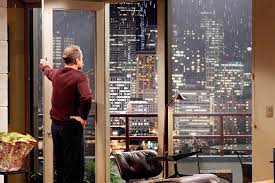

## 1. Data Loading and Scope
In this section, I load the joined King County housing dataset into a pandas DataFrame and confirm the scope of the data (rows, columns, and time range). This ensures the analysis starts from a consistent and reproducible dataset snapshot.

In [140]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from matplotlib.ticker import PercentFormatter
plt.rcParams.update({ "figure.figsize" : (8, 5),"axes.facecolor" : "white", "axes.edgecolor":  "black"})
plt.rcParams["figure.facecolor"]= "w"
pd.plotting.register_matplotlib_converters()
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [141]:
df_housing = pd.read_csv('data/eda.csv')

In [142]:
df_housing.shape

(21597, 22)

In [143]:
df_housing.columns

Index(['house_id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'sale_id', 'sale_date', 'sale_price'],
      dtype='object')

In [144]:
df_housing.head(10)

,house_id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_id,sale_date,sale_price
0,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,3,7,...,1955,0.000,98178,47.511,-122.257,1340.000,5650.000,1,2014-10-13,221900.000
1,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,3,7,...,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000,2,2014-12-09,538000.000
2,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,3,6,...,1933,NaN,98028,47.738,-122.233,2720.000,8062.000,3,2015-02-25,180000.000
3,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,5,7,...,1965,0.000,98136,47.521,-122.393,1360.000,5000.000,4,2014-12-09,604000.000
4,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,3,8,...,1987,0.000,98074,47.617,-122.045,1800.000,7503.000,5,2015-02-18,510000.000
5,7237550310,4.000,4.500,5420.000,101930.000,1.000,0.000,0.000,3,11,...,2001,0.000,98053,47.656,-122.005,4760.000,101930.000,6,2014-05-12,1230000.000
6,1321400060,3.000,2.250,1715.000,6819.000,2.000,0.000,0.000,3,7,...,1995,0.000,98003,47.310,-122.327,2238.000,6819.000,7,2014-06-27,257500.000
7,2008000270,3.000,1.500,1060.000,9711.000,1.000,0.000,NaN,3,7,...,1963,0.000,98198,47.410,-122.315,1650.000,9711.000,8,2015-01-15,291850.000
8,2414600126,3.000,1.000,1780.000,7470.000,1.000,0.000,0.000,3,7,...,1960,0.000,98146,47.512,-122.337,1780.000,8113.000,9,2015-04-15,229500.000
9,3793500160,3.000,2.500,1890.000,6560.000,2.000,0.000,0.000,3,7,...,2003,0.000,98038,47.368,-122.031,2390.000,7570.000,10,2015-03-12,323000.000


In [145]:
df_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   house_id       21597 non-null  int64  
 1   bedrooms       21597 non-null  float64
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  float64
 4   sqft_lot       21597 non-null  float64
 5   floors         21597 non-null  float64
 6   waterfront     19206 non-null  float64
 7   view           21534 non-null  float64
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  float64
 11  sqft_basement  21145 non-null  float64
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  float64
 18  sqft_l

In [146]:
df_housing['house_id'].nunique()

21420

In [147]:
df_housing.describe().T

,count,mean,std,min,25%,50%,75%,max
house_id,21597.000,4580474287.771,2876735715.748,1000102.000,2123049175.000,3904930410.000,7308900490.000,9900000190.000
bedrooms,21597.000,3.373,0.926,1.000,3.000,3.000,4.000,33.000
bathrooms,21597.000,2.116,0.769,0.500,1.750,2.250,2.500,8.000
sqft_living,21597.000,2080.322,918.106,370.000,1430.000,1910.000,2550.000,13540.000
sqft_lot,21597.000,15099.409,41412.637,520.000,5040.000,7618.000,10685.000,1651359.000
floors,21597.000,1.494,0.540,1.000,1.000,1.500,2.000,3.500
waterfront,19206.000,0.008,0.087,0.000,0.000,0.000,0.000,1.000
view,21534.000,0.234,0.766,0.000,0.000,0.000,0.000,4.000
condition,21597.000,3.410,0.651,1.000,3.000,3.000,4.000,5.000
grade,21597.000,7.658,1.173,3.000,7.000,7.000,8.000,13.000


In [148]:
df_housing.isna().sum().sort_values(ascending=False)

yr_renovated     3848
waterfront       2391
sqft_basement     452
view               63
yr_built            0
sale_date           0
sale_id             0
sqft_lot15          0
sqft_living15       0
long                0
lat                 0
zipcode             0
house_id            0
bedrooms            0
sqft_above          0
grade               0
condition           0
floors              0
sqft_lot            0
sqft_living         0
bathrooms           0
sale_price          0
dtype: int64

**Observation**

At this stage, we explored the basic structure of the dataset to understand its scope and data quality. The dataset contains 21,597 rows and 22 features, representing housing transactions in King County. By inspecting the columns and data types, we observed that most features are numerical, while some variables such as sale_date are currently stored as objects and will require type conversion in later steps.

We also found that the number of unique house_id values is slightly lower than the total number of rows, which indicates that around 177 houses were sold more than once. This confirms that the dataset includes repeat sales and that individual houses may appear multiple times with different sale records.

In addition, several features contain missing values. The most notable missing data appear in yr_renovated, waterfront, sqft_basement, and view. These missing values will need to be handled carefully in the data cleaning phase, as they may carry meaningful information rather than being purely random.

Finally, an initial inspection of the renovation year variable suggests a potential data quality issue, where some renovation years may include an extra zero. This will be investigated further in the next step of the analysis.

## 2. Data Cleaning

### 2.1 Data Type Adjustment
In this step, we focused on adjusting data types where necessary to support exploratory analysis, while keeping transformations minimal and safe.

Identifier variables such as house_id and sale_id were intentionally kept as integer types. These variables act purely as identifiers and do not represent numerical quantities, so converting them to other data types would not add analytical value.

The sale_date column was converted from object to datetime format. This change enables time based analysis in later stages, such as monthly trends, seasonality effects, and temporal comparisons.

Other variables were deliberately left unchanged at this point. Features like condition, grade, and view are ordinal by nature, but they remain in numeric form for now to keep the dataset flexible during early exploration. The waterfront variable is binary, but due to the presence of missing values, it is currently stored as a float.

The yr_renovated feature represents a year rather than a full date and therefore was not converted to a datetime format. Any issues related to this variable, such as potential value inconsistencies, are considered data quality concerns and will be addressed in a later cleaning step rather than as part of data type changes.

At this stage, the goal is to prepare the dataset for exploration without making assumptions that could affect downstream analysis.

In [150]:
# Keep identifiers as integers (used only for reference, not analysis)
df_housing[['house_id', 'sale_id']] = df_housing[['house_id', 'sale_id']].astype('int64')

In [151]:
# Convert sale_date from object to datetime for time-based analysis
df_housing['sale_date'] = pd.to_datetime(df_housing['sale_date'])


In [152]:
# Check data types after applying safe conversions
df_housing.dtypes

house_id                  int64
bedrooms                float64
bathrooms               float64
sqft_living             float64
sqft_lot                float64
floors                  float64
waterfront              float64
view                    float64
condition                 int64
grade                     int64
sqft_above              float64
sqft_basement           float64
yr_built                  int64
yr_renovated            float64
zipcode                   int64
lat                     float64
long                    float64
sqft_living15           float64
sqft_lot15              float64
sale_id                   int64
sale_date        datetime64[ns]
sale_price              float64
dtype: object

### 2.2 Data Quality Check: Fixing yr_renovated values
In this step, we performed a focused data quality check on the yr_renovated column. By inspecting the non-zero renovation values, we observed a systematic formatting issue where an extra zero had been appended to the year, making the values invalid as actual renovation years. Since this pattern was consistent across the affected rows, it was treated as a data entry error and corrected accordingly.

In addition, a new binary feature was_renovated was created to clearly distinguish between renovated and non-renovated houses, independent of the exact renovation year.

In [153]:
# Fix yr_renovated values with systematic trailing zero (e.g., 19910 -> 1991), then create was_renovated

# 1) Convert to numeric safely (keeps NaN)
yr = pd.to_numeric(df_housing['yr_renovated'], errors='coerce')

# 2) Fix values like 19910.0 -> 1991 (5 digits and ends with 0)
mask_trailing_zero = yr.notna() & (yr >= 10000) & (yr <= 30000) & (yr % 10 == 0)
yr.loc[mask_trailing_zero] = yr.loc[mask_trailing_zero] / 10

# 3) Write back as integer-like (still allowing NaN for now)
df_housing['yr_renovated'] = yr

# 4) Create renovation flag (1 if renovated year > 0, else 0)
df_housing['was_renovated'] = (df_housing['yr_renovated'].fillna(0) > 0).astype(int)

# 5) Replace missing renovation years with 0 for consistency (not renovated)
df_housing['yr_renovated'] = df_housing['yr_renovated'].fillna(0).astype(int)

df_housing[['yr_renovated', 'was_renovated']].head(10)


,yr_renovated,was_renovated
0,0,0
1,1991,1
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [154]:
# Count how many houses were renovated vs not renovated
df_housing['was_renovated'].value_counts()

was_renovated
0    20853
1      744
Name: count, dtype: int64

### 2.3 Handling Missing Values
In this step, missing values were handled based on domain knowledge and the meaning of each feature rather than using purely statistical imputation.

Renovation-related missing values were already addressed in the previous step by treating both missing and zero values in yr_renovated as indicating no renovation. A binary feature (was_renovated) was created to explicitly capture renovation status, so no further handling was needed here.

For the remaining features, missing values were interpreted as the absence of that characteristic. Missing sqft_basement values were assumed to indicate houses without a basement and were set to zero. Similarly, missing values in waterfront were treated as non-waterfront properties, and missing view values were interpreted as houses without a notable view.

After applying these assumptions, all missing values in the dataset were resolved, resulting in a complete dataset suitable for subsequent analysis and modeling.

In [155]:
# Check missing values per column
df_housing.isna().sum().sort_values(ascending=False)

waterfront       2391
sqft_basement     452
view               63
yr_renovated        0
sale_price          0
sale_date           0
sale_id             0
sqft_lot15          0
sqft_living15       0
long                0
lat                 0
zipcode             0
house_id            0
yr_built            0
bedrooms            0
sqft_above          0
grade               0
condition           0
floors              0
sqft_lot            0
sqft_living         0
bathrooms           0
was_renovated       0
dtype: int64

In [156]:
# Missing basement area likely indicates no basement
df_housing['sqft_basement'] = df_housing['sqft_basement'].fillna(0)

In [157]:
# Missing waterfront values are assumed to be non-waterfront houses
df_housing['waterfront'] = df_housing['waterfront'].fillna(0)

In [158]:
# Missing view values are treated as no view
df_housing['view'] = df_housing['view'].fillna(0)

In [159]:
# Verify that all missing values have been handled
df_housing.isna().sum()

house_id         0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
sale_id          0
sale_date        0
sale_price       0
was_renovated    0
dtype: int64

In [160]:
df_housing.describe().T

,count,mean,min,25%,50%,75%,max,std
house_id,21597.000,4580474287.771,1000102.000,2123049175.000,3904930410.000,7308900490.000,9900000190.000,2876735715.748
bedrooms,21597.000,3.373,1.000,3.000,3.000,4.000,33.000,0.926
bathrooms,21597.000,2.116,0.500,1.750,2.250,2.500,8.000,0.769
sqft_living,21597.000,2080.322,370.000,1430.000,1910.000,2550.000,13540.000,918.106
sqft_lot,21597.000,15099.409,520.000,5040.000,7618.000,10685.000,1651359.000,41412.637
floors,21597.000,1.494,1.000,1.000,1.500,2.000,3.500,0.540
waterfront,21597.000,0.007,0.000,0.000,0.000,0.000,1.000,0.082
view,21597.000,0.233,0.000,0.000,0.000,0.000,4.000,0.765
condition,21597.000,3.410,1.000,3.000,3.000,4.000,5.000,0.651
grade,21597.000,7.658,3.000,7.000,7.000,8.000,13.000,1.173


##  3. Exploratory Data Analysis
In this stage, the goal was to explore the data in a structured and hypothesis-driven way rather than performing an exhaustive analysis of all possible feature combinations. The focus of the EDA was aligned with the project’s main hypotheses and the client’s decision-making context, particularly around price drivers, renovation effects, location, and property characteristics.

Instead of analyzing every feature against every other feature, the exploration was guided by relevance. Features that were directly connected to the defined hypotheses received more attention, while others were reviewed only at a high level. This approach helped keep the analysis focused, interpretable, and directly useful for answering the project’s core questions.

### 3.1 Univariate Distributions
As a first step within the EDA, univariate distributions were examined to understand the individual behavior of key features. This included reviewing the overall shape, spread, and potential skewness of variables relevant to pricing and renovation-related hypotheses.

At this stage, the analysis was limited to single-feature distributions without considering interactions between variables. The goal was to build an initial intuition about the data, identify extreme values, and assess whether transformations or special handling might be needed in later steps.

#### 3.1.1 Continuous Features

For the continuous features, we start by examining their univariate distributions to understand their overall scale, spread, and shape. This includes reviewing both distribution plots and box plots to capture skewness, variability, and the presence of extreme values.

At this stage, the goal is not to draw conclusions, but to build intuition about the data and identify patterns that may require transformations or special treatment in later analysis steps. Group Continuous Features:
    'sale_price',
    'sqft_living',
    'sqft_above',
    'sqft_basement',
    'sqft_living15',
    'sqft_lot',
    'sqft_lot15'

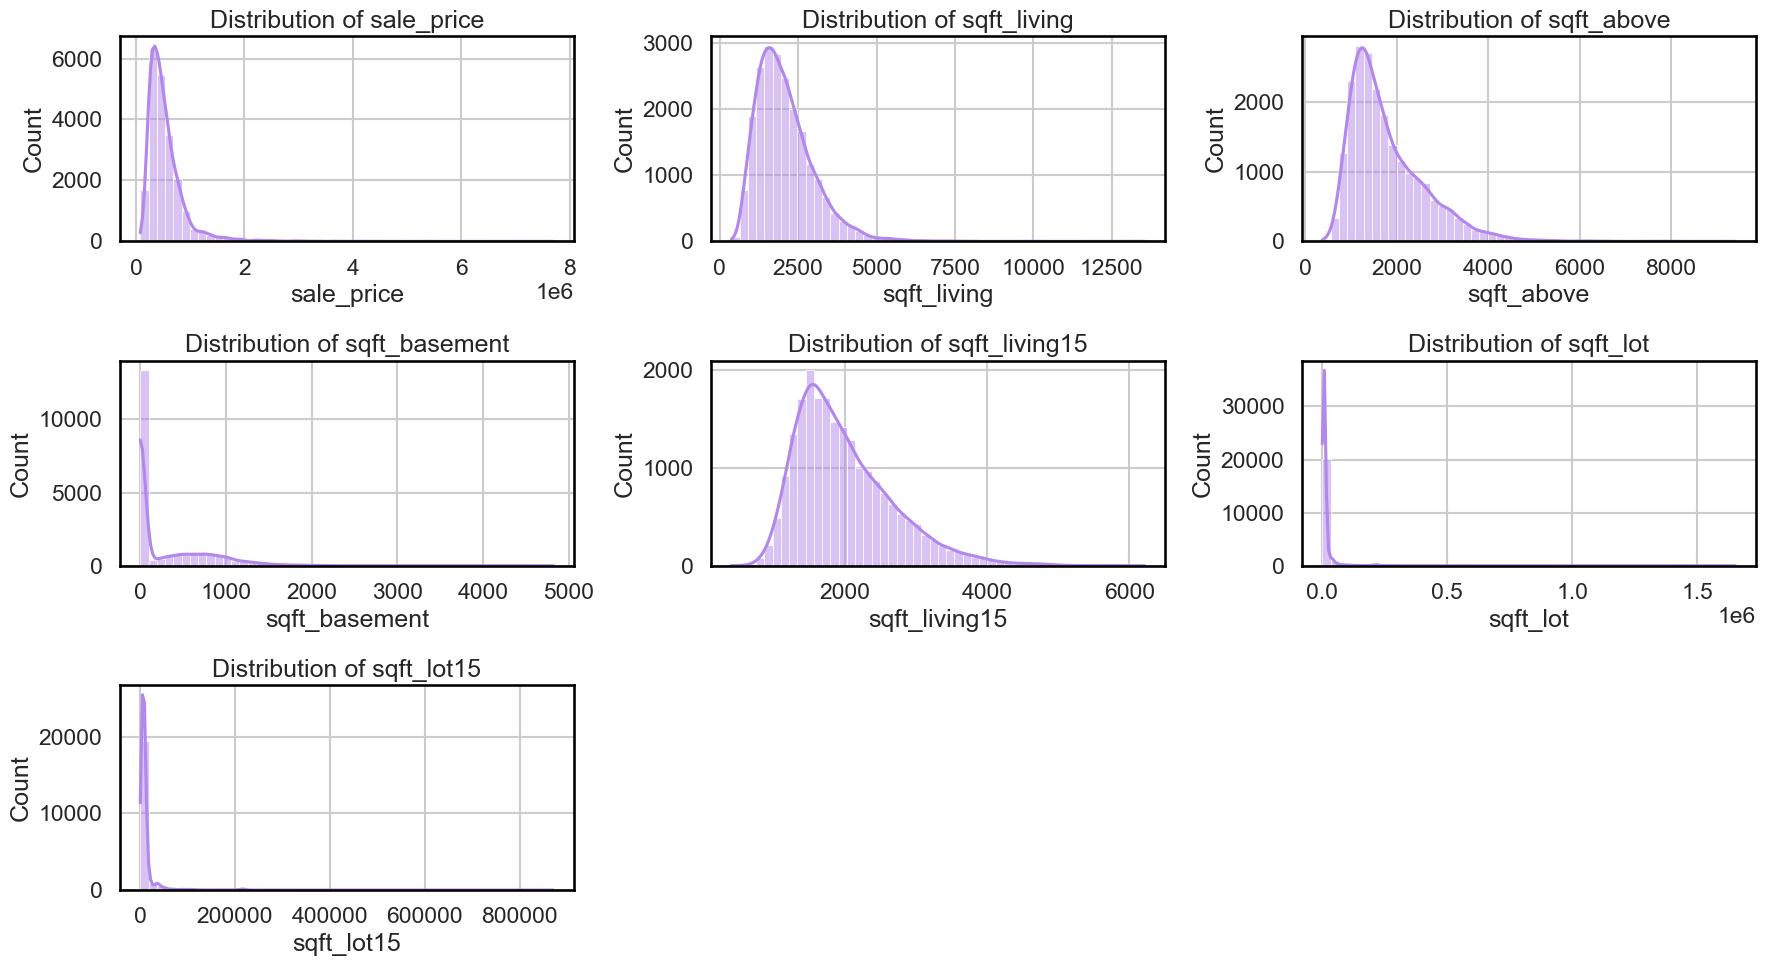

In [161]:
# Distribution plots for countinuos features to inspect patterns 

size_features = [
    'sale_price',
    'sqft_living',
    'sqft_above',
    'sqft_basement',
    'sqft_living15',
    'sqft_lot',
    'sqft_lot15'
]

plt.figure(figsize=(18, 10))

for i, col in enumerate(size_features, 1):
    plt.subplot(3, 3, i)
    
    sns.histplot(
        df_housing[col],
        bins=50,
        kde=True,
        color='#B388EB',
        edgecolor=None
    )
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()


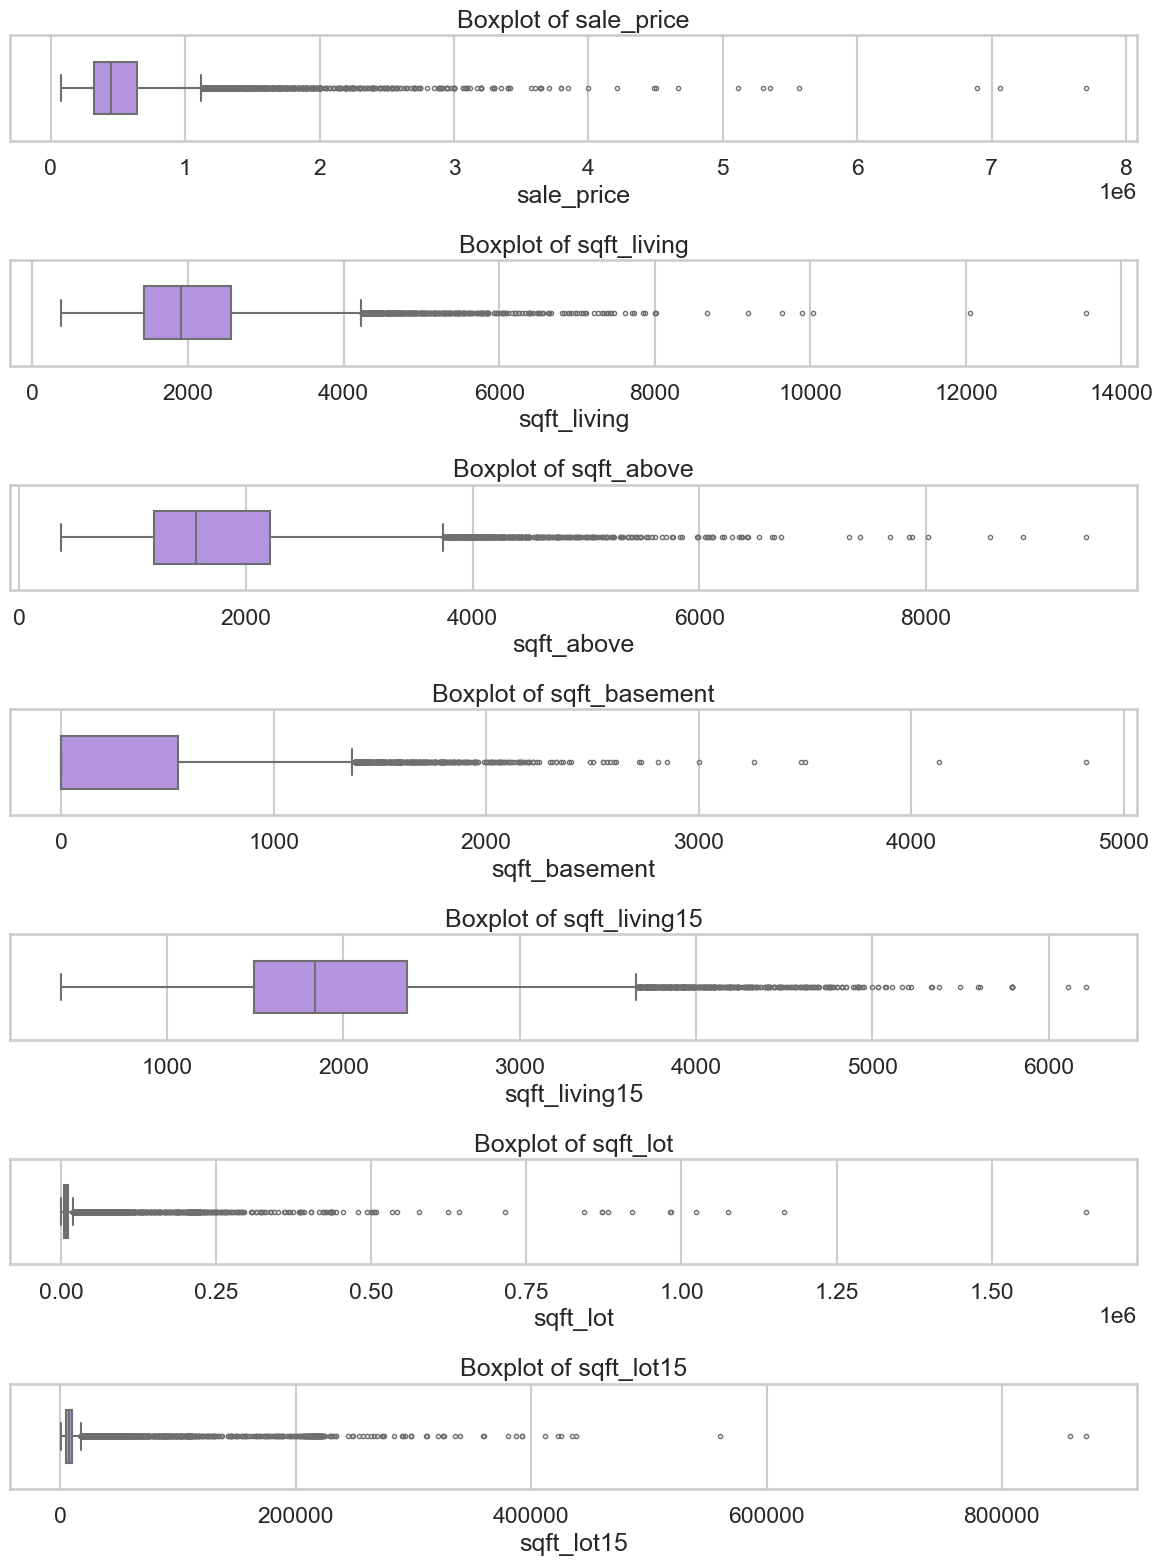

In [162]:
# Boxplots for continuous features to examine spread 
size_features = [
    'sale_price',
    'sqft_living',
    'sqft_above',
    'sqft_basement',
    'sqft_living15',
    'sqft_lot',
    'sqft_lot15'
]

sns.set_theme(
    style="whitegrid",
    context="talk"
)

plt.figure(figsize=(12, 16))

for i, col in enumerate(size_features, 1):
    plt.subplot(7, 1, i)
    
    sns.boxplot(
        x=df_housing[col],
        color='#B388EB',
        width=0.5,
        fliersize=3,
        linewidth=1.5
    )
    
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()


**Observation**

Across all examined continuous size-related features, the distributions are clearly right-skewed. Most observations are concentrated at lower values, while a long tail extends toward higher values. This pattern is consistently visible in both the histograms and the boxplots.

The boxplots also reveal a substantial number of extreme values on the upper end of the distributions. At this stage, these points are treated as potential outliers, but no assumptions are made yet about whether they represent data errors or genuinely large properties. A more careful evaluation of these values will be carried out later in the analysis.

Given the strong right skewness and the presence of extreme values across all size-related features, a logarithmic transformation is considered in the next step to reduce skewness and obtain distributions that are closer to symmetric, which can be beneficial for downstream analysis and modeling.

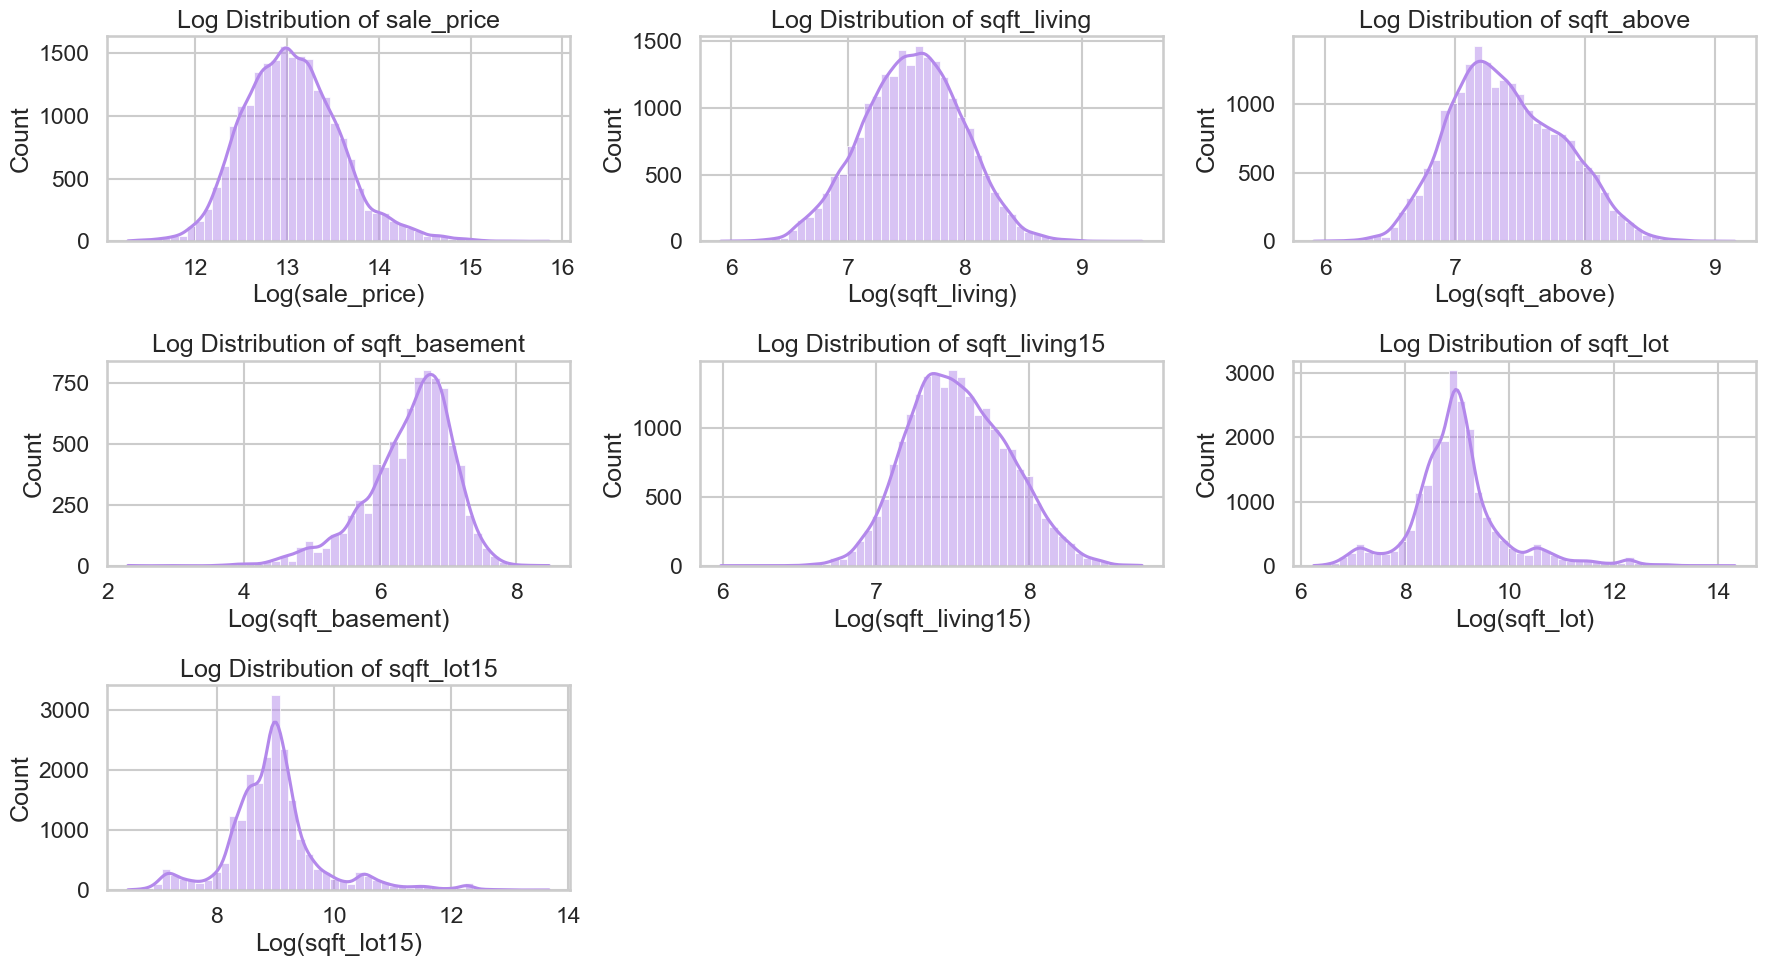

In [163]:
# Distribution plots for log of countinuos features to inspect patterns

size_features = [
    'sale_price',
    'sqft_living',
    'sqft_above',
    'sqft_basement',
    'sqft_living15',
    'sqft_lot',
    'sqft_lot15'
]

plt.figure(figsize=(18, 10))

for i, col in enumerate(size_features, 1):
    plt.subplot(3, 3, i)
    
    sns.histplot(
        np.log(df_housing[col]),
        bins=50,
        kde=True,
        color='#B388EB',
        edgecolor=None
    )
    
    plt.title(f'Log Distribution of {col}')
    plt.xlabel(f'Log({col})')

plt.tight_layout()
plt.show()


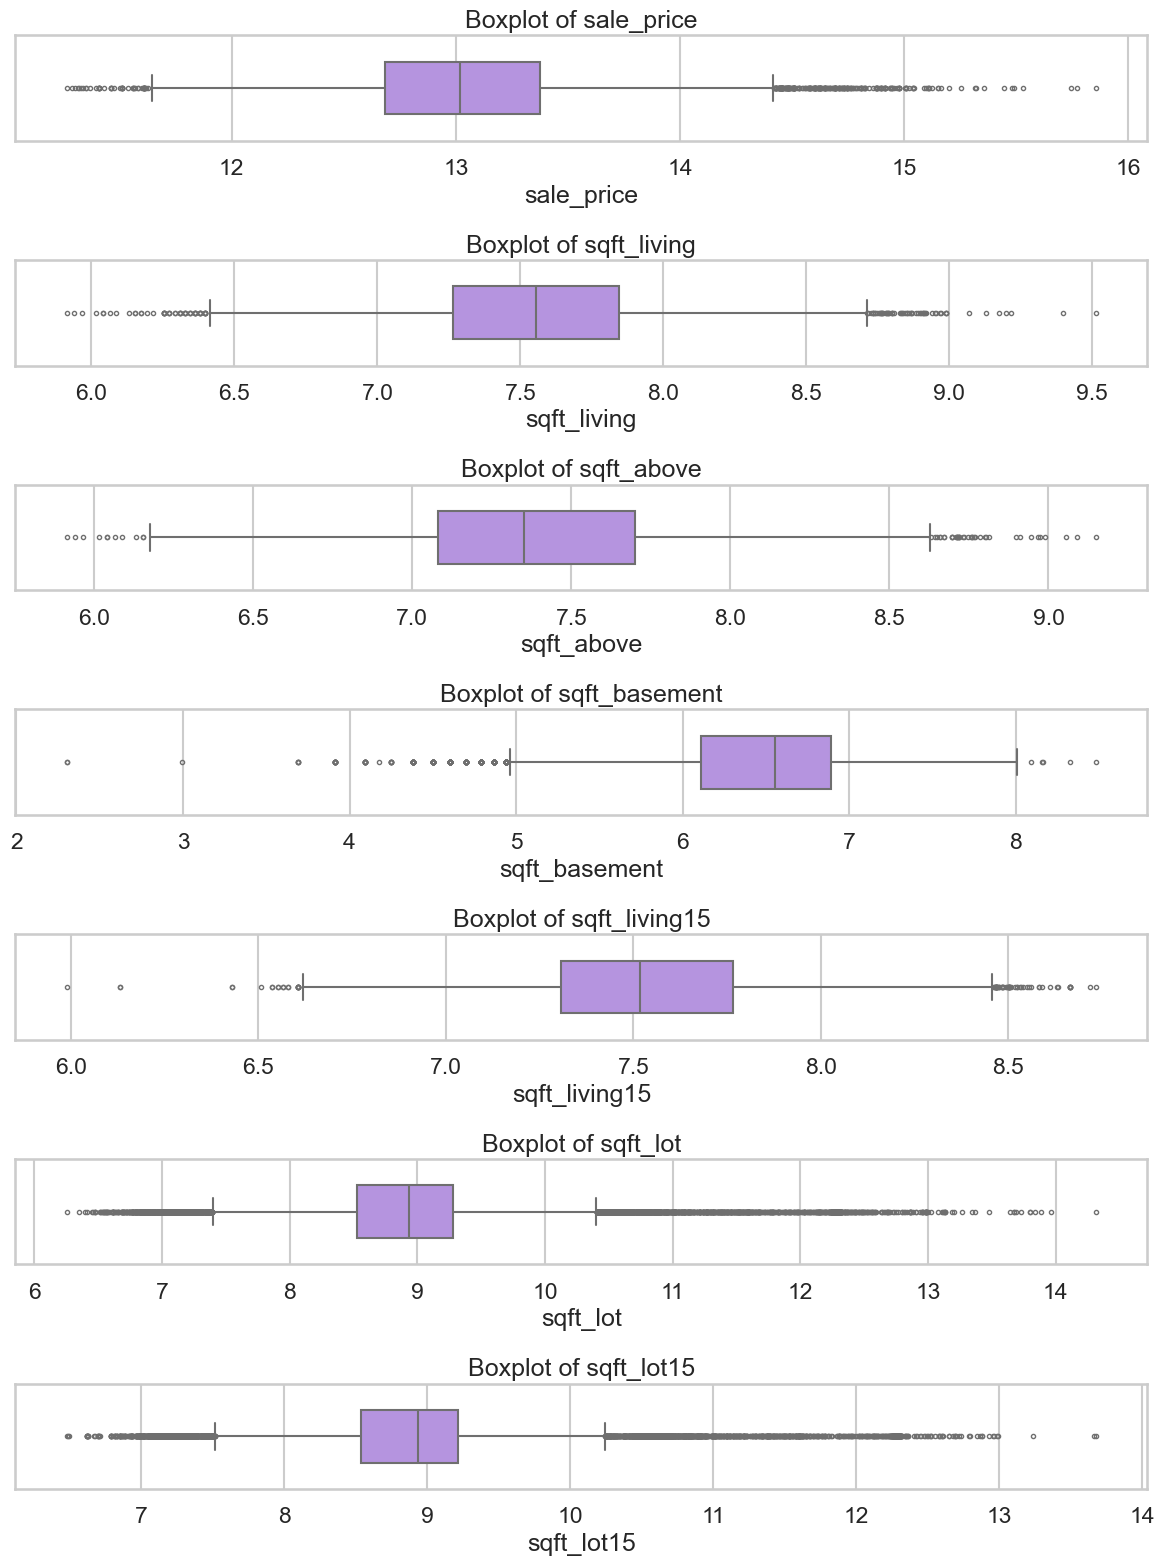

In [164]:

size_features = [
    'sale_price',
    'sqft_living',
    'sqft_above',
    'sqft_basement',
    'sqft_living15',
    'sqft_lot',
    'sqft_lot15'
]

sns.set_theme(
    style="whitegrid",
    context="talk"
)

plt.figure(figsize=(12, 16))

for i, col in enumerate(size_features, 1):
    plt.subplot(7, 1, i)
    
    sns.boxplot(
        x=np.log(df_housing[col]),
        color='#B388EB',
        width=0.5,
        fliersize=3,
        linewidth=1.5
    )
    
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()


**Observation**

The univariate distributions of the continuous features show a strong right skew across almost all variables, with a long tail of large values. This pattern is also clearly visible in the boxplots, where a substantial number of extreme values appear on the upper end of the distributions.
After applying a logarithmic transformation, the distributions become more symmetric and closer to a normal shape. The corresponding boxplots indicate a more balanced spread of the data, while extreme values remain identifiable but less dominant. Overall, the log transformation improves the interpretability of the distributions and provides a more suitable basis for subsequent analysis and modeling.

#### 3.1.2 Discret Features
In this stage, the focus is on discrete-valued features, including count-based, binary, and ordinal variables. These features take on a limited set of possible values and therefore exhibit distribution patterns that differ from continuous variables.

For these features, we inspect both their frequency distributions and boxplots to understand how values are distributed across categories, identify dominant levels, and detect potential irregularities or extreme cases. Although some of these variables are ordinal by nature, they are analyzed together here due to their discrete structure and low cardinality.

This step provides a clearer understanding of how discrete property characteristics are represented in the dataset and prepares the ground for more targeted relational analysis in later stages.

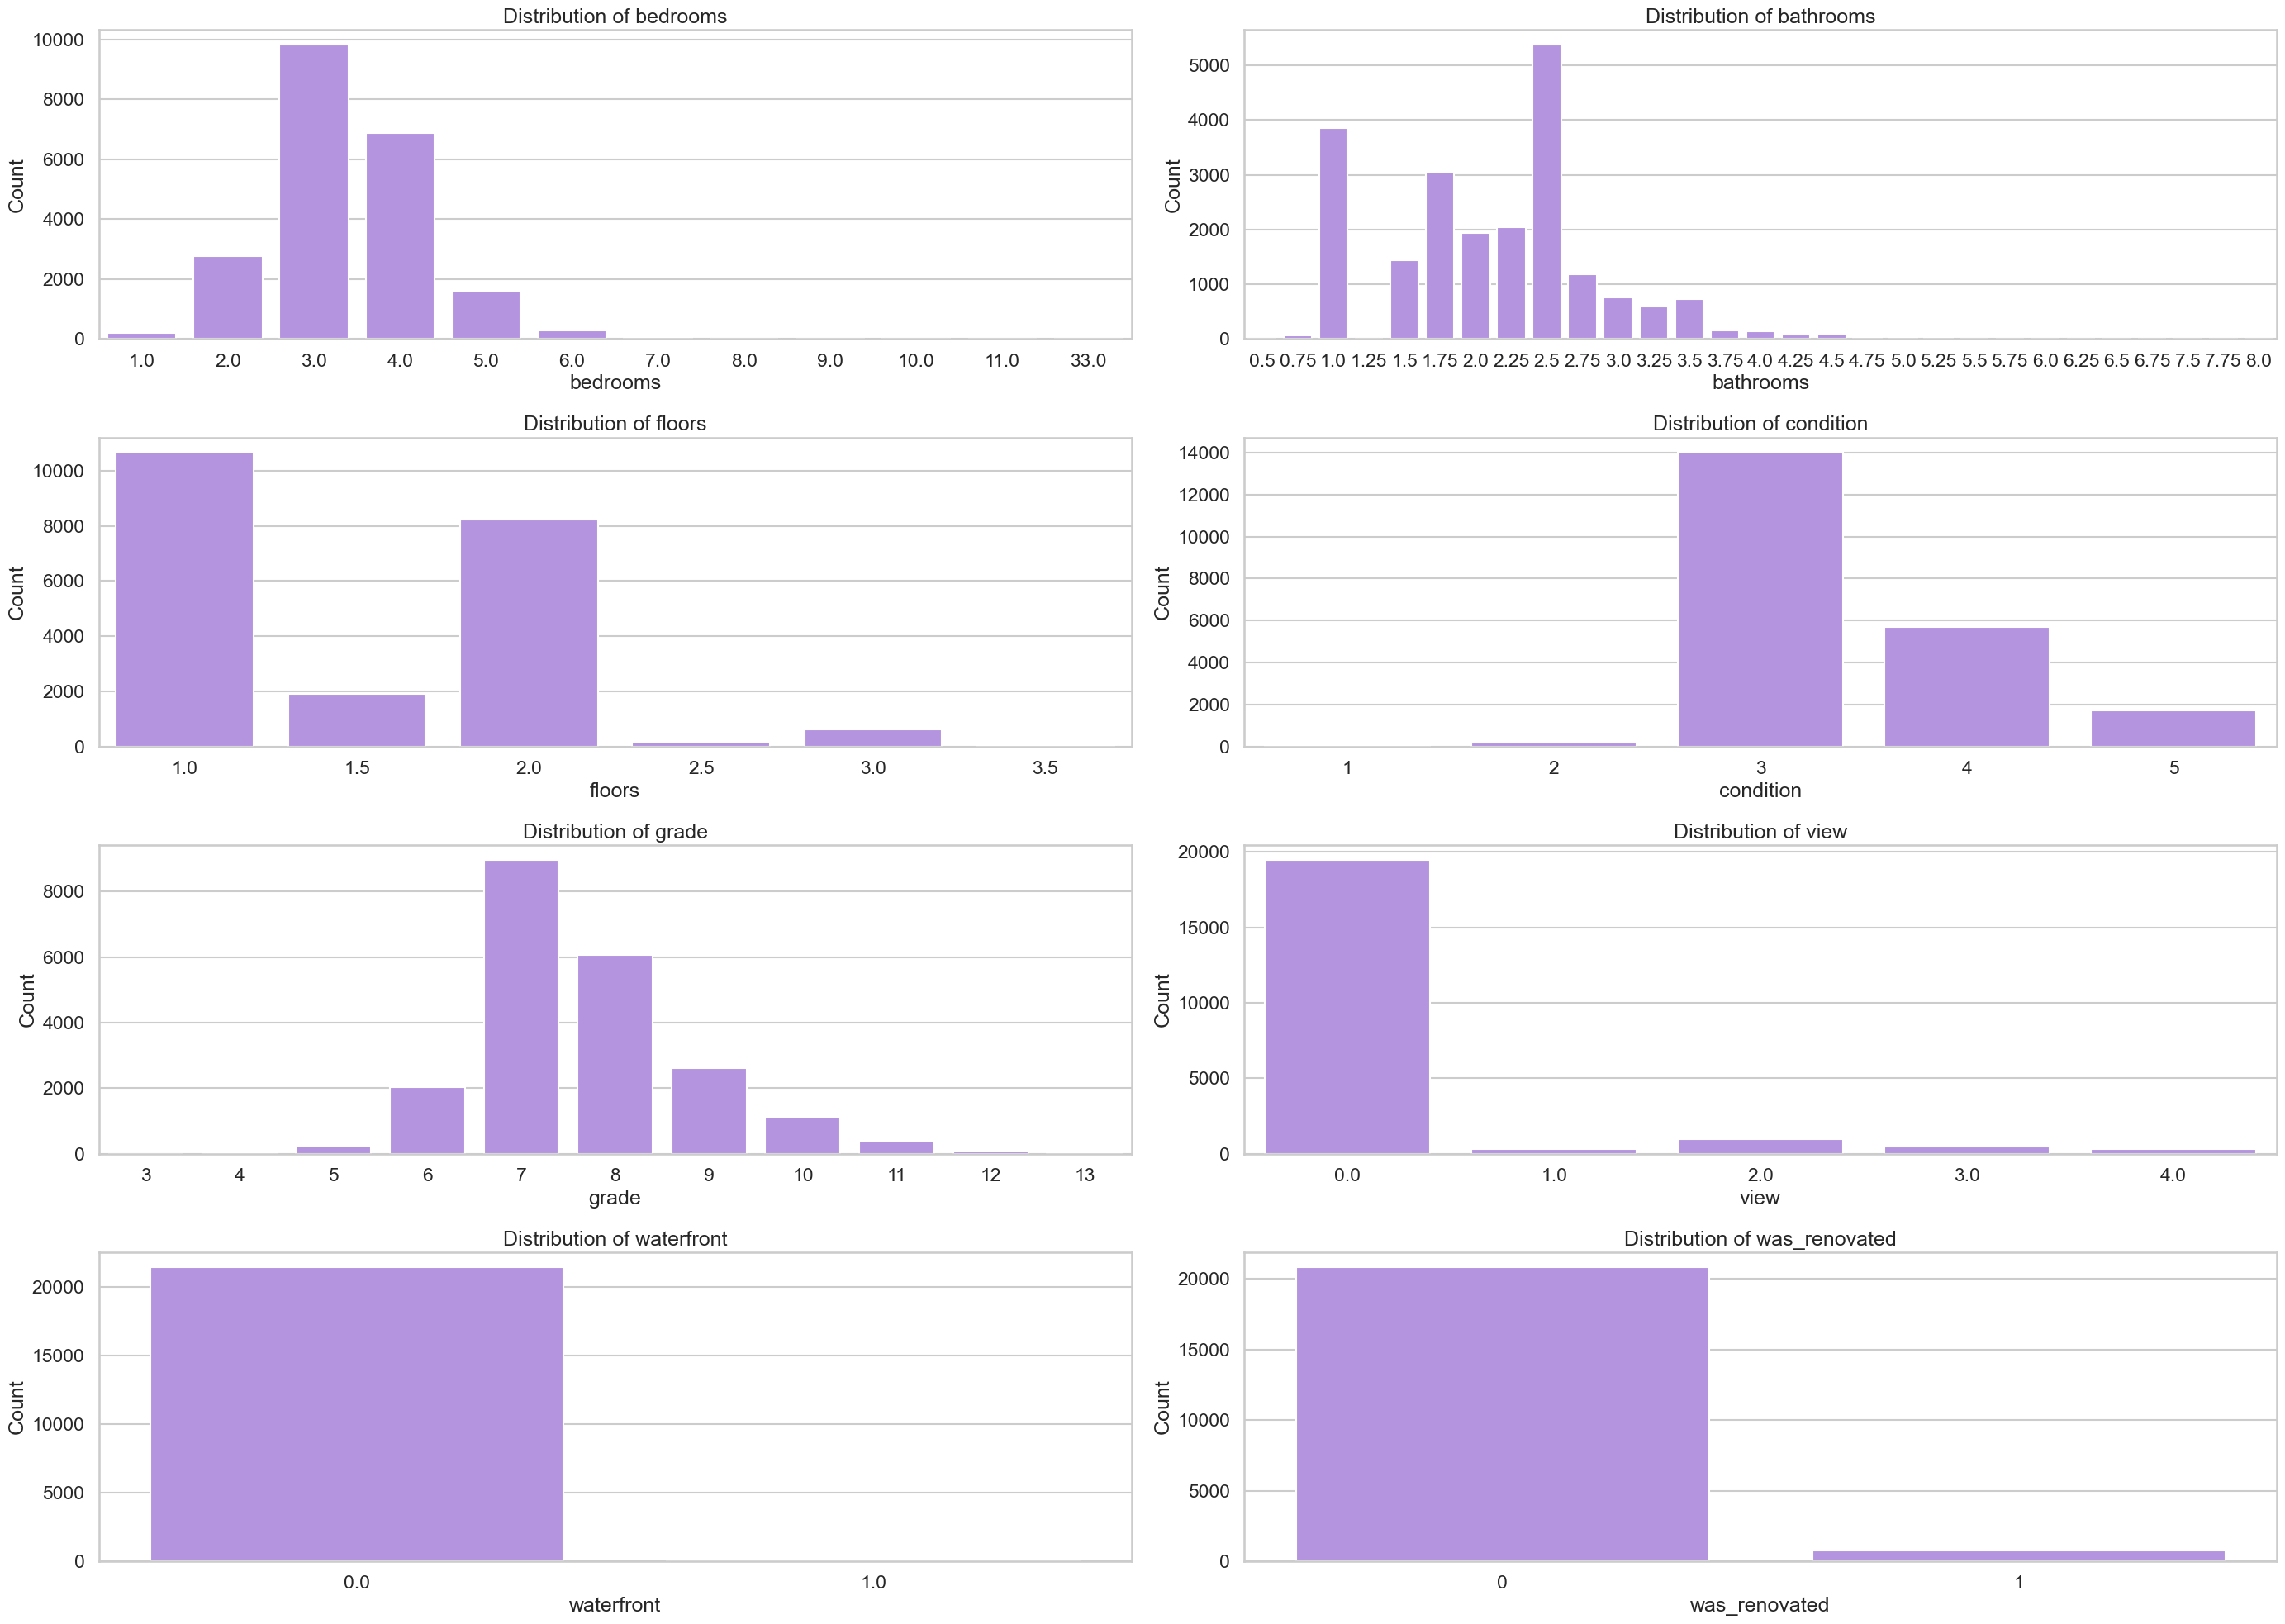

In [165]:
# Distribution plots for discrete features to inspect frequency patterns and dominant categories

import matplotlib.pyplot as plt
import seaborn as sns

discrete_features = [
    'bedrooms',
    'bathrooms',
    'floors',
    'condition',
    'grade',
    'view',
    'waterfront',
    'was_renovated'
]

sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(4, 2, figsize=(28, 20))
axes = axes.flatten()

for ax, col in zip(axes, discrete_features):
    sns.countplot(
        x=df_housing[col],
        ax=ax,
        color='#B388EB'
    )
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# Remove empty subplots if any
for i in range(len(discrete_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


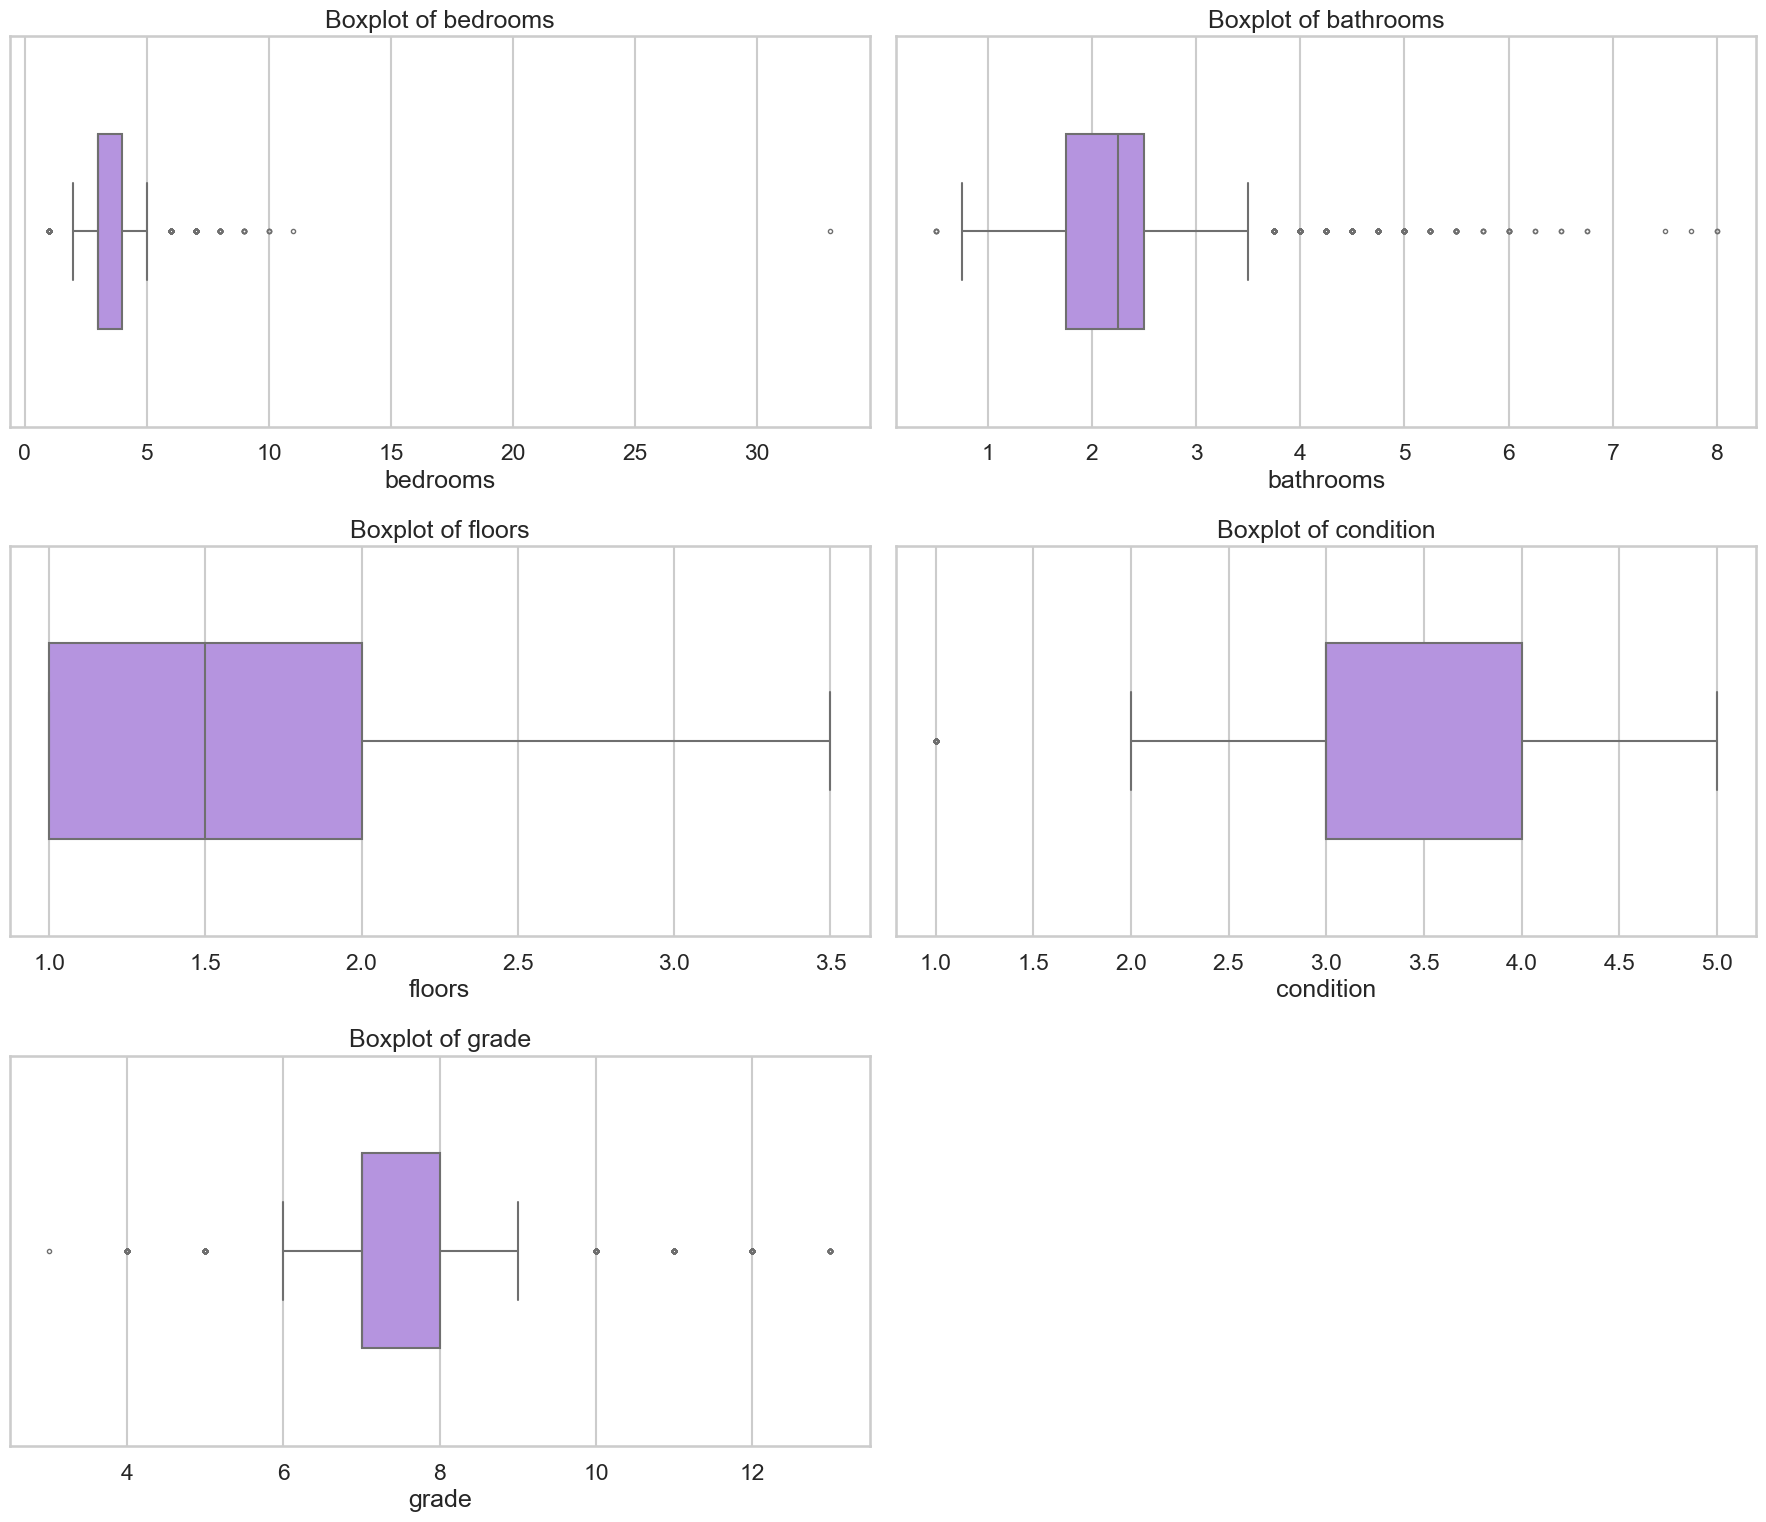

In [166]:
# Boxplots for discrete features to examine spread and potential outliers

import matplotlib.pyplot as plt
import seaborn as sns

discrete_features = [
    'bedrooms',
    'bathrooms',
    'floors',
    'condition',
    'grade',
    #'view',
    #'waterfront',
    #'was_renovated'
]

sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

for ax, col in zip(axes, discrete_features):
    sns.boxplot(
        x=df_housing[col],
        ax=ax,
        color='#B388EB',
        width=0.5,
        fliersize=3,
        linewidth=1.5
    )
    ax.set_title(f'Boxplot of {col}')
    ax.set_xlabel(col)

# Remove empty subplots if any
for i in range(len(discrete_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


**Observation**
The distributions of discrete features such as bedrooms, bathrooms, floors, condition, and grade show clear concentration around a small number of typical values. Most properties have between 2 and 4 bedrooms, with a noticeable peak at 3 bedrooms. A small number of extreme values is observed, most notably a property with 33 bedrooms, which is likely a data entry anomaly. Since these extreme values are not directly relevant to the current analysis objectives, they were not modified at this stage and will be revisited later if needed.

Boxplots confirm the presence of outliers in several discrete features; however, given the discrete and ordinal nature of these variables, no transformations such as logarithmic scaling were applied. At this stage, the focus remains on understanding the overall distribution patterns rather than altering the data.

#### 3.1.3 Discret Temporal and Identifier Features
This section explores numeric features that are neither continuous size variables nor discrete counts. These features mainly represent time, location, or identifiers and are reviewed to understand their structure and potential role in later analysis.

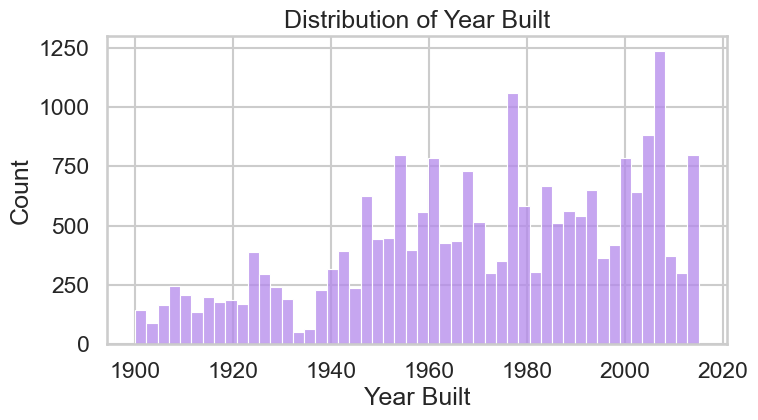

In [167]:
# -----------------------------
# yr_built distribution
# -----------------------------
plt.figure(figsize=(8, 4))
sns.histplot(df_housing['yr_built'], bins=50, color='#B388EB')
plt.title('Distribution of Year Built')
plt.xlabel('Year Built')
plt.show()



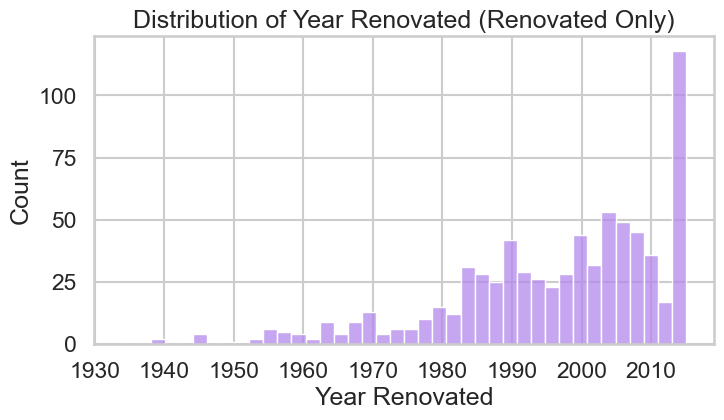

In [168]:
# -----------------------------
# yr_renovated distribution (after cleaning)
# -----------------------------
plt.figure(figsize=(8, 4))
sns.histplot(
    df_housing.loc[df_housing['yr_renovated'] > 0, 'yr_renovated'],
    bins=40,
    color='#B388EB'
)
plt.title('Distribution of Year Renovated (Renovated Only)')
plt.xlabel('Year Renovated')
plt.show()

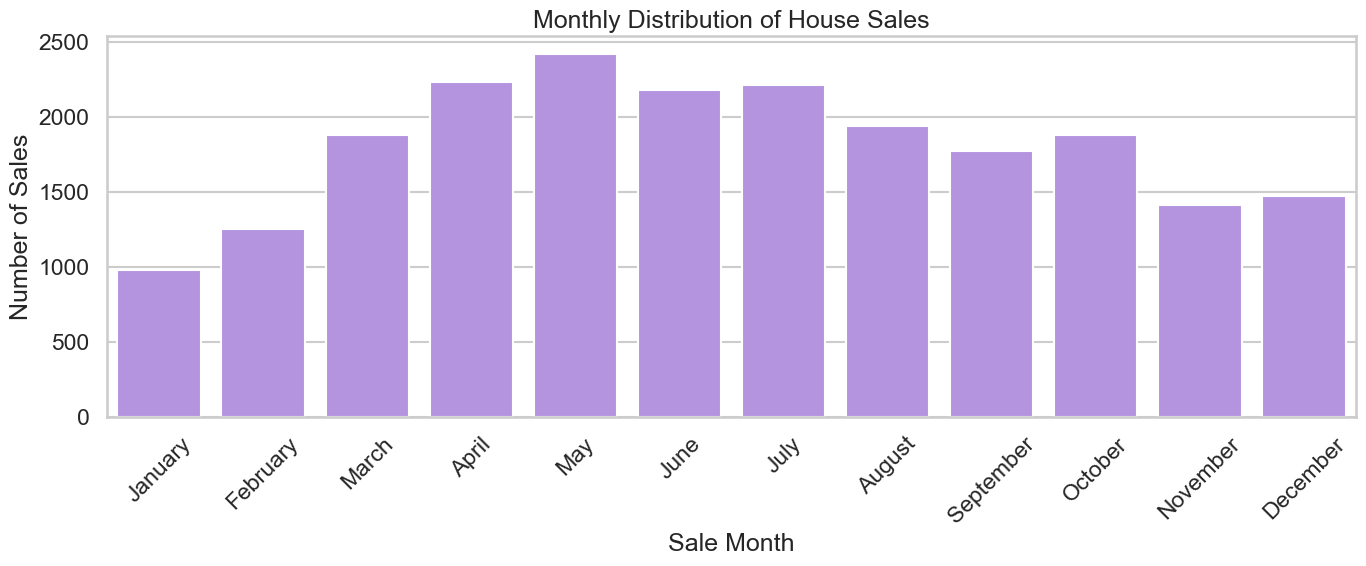

In [169]:
# Monthly distribution of sales using month names
# Ensure sale_date is datetime
df_housing['sale_date'] = pd.to_datetime(df_housing['sale_date'])

# Extract year and month name
df_housing['sale_year'] = df_housing['sale_date'].dt.year
df_housing['sale_month'] = df_housing['sale_date'].dt.month_name()

# Keep chronological month order
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

plt.figure(figsize=(14, 6))

sns.countplot(
    data=df_housing,
    x='sale_month',
    order=month_order,
    color='#B388EB'
)

plt.title('Monthly Distribution of House Sales')
plt.xlabel('Sale Month')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


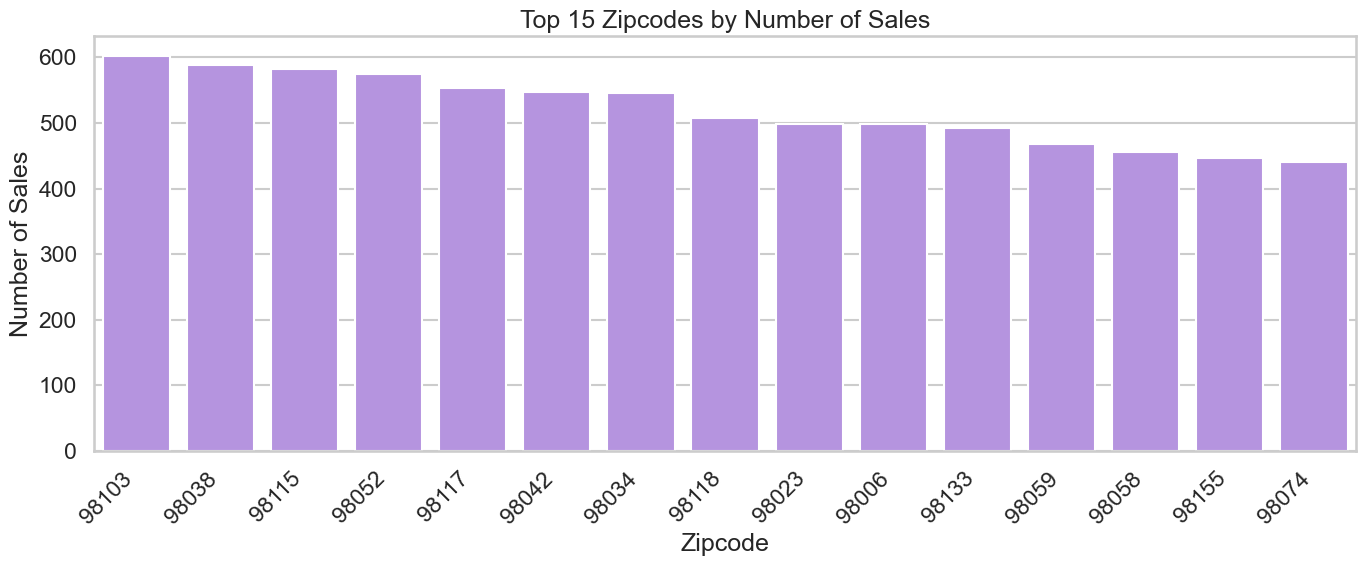

In [170]:
# Plot top 15 zipcodes by frequency (number of sales)
import seaborn as sns
import matplotlib.pyplot as plt

top_zipcodes = df_housing['zipcode'].value_counts().head(15)

plt.figure(figsize=(14, 6))
sns.barplot(
    x=top_zipcodes.index.astype(str),   # zipcode categories
    y=top_zipcodes.values,  
    color='#B388EB'             # counts
)

plt.title('Top 15 Zipcodes by Number of Sales')
plt.xlabel('Zipcode')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


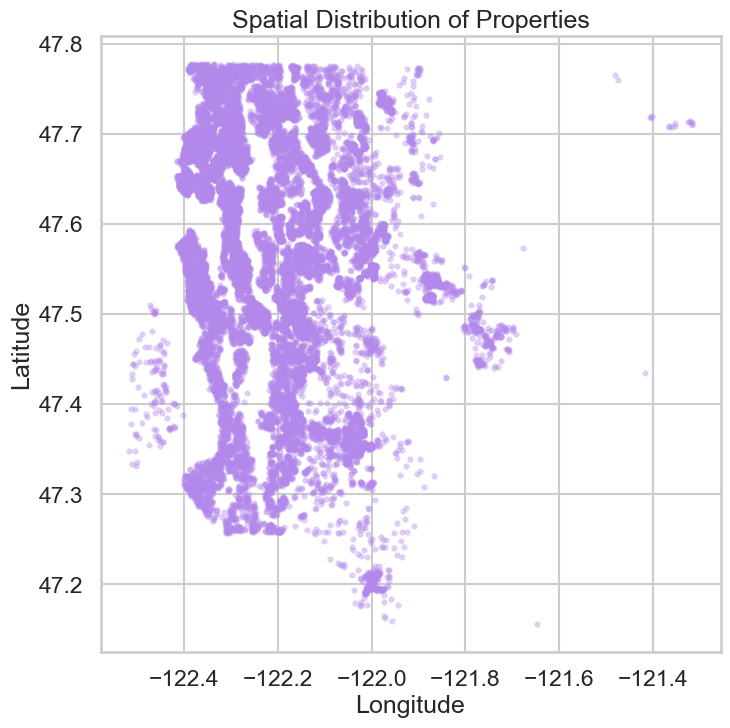

In [171]:
# -----------------------------
# Spatial spread (lat / long)
# -----------------------------
plt.figure(figsize=(8, 8))
plt.scatter(
    df_housing['long'],
    df_housing['lat'],
    alpha=0.3,
    s=10,
    color='#B388EB'
)
plt.title('Spatial Distribution of Properties')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

**observation**
From the temporal and identifier-based visualizations, renovation activity appears to be concentrated in more recent decades, with a noticeable increase after the 1980s and a peak in the 2000s. This suggests a growing tendency toward renovating older properties rather than replacing them.

The distribution of sales by year shows a higher transaction volume in 2014 compared to 2015, which is consistent with the dataset covering only a partial period for the latter year.

Analysis of zipcode frequencies indicates that housing transactions are not evenly distributed across locations. Instead, a relatively small number of zipcodes account for a substantial share of total sales, pointing to higher market activity in specific neighborhoods.

Finally, the latitude–longitude scatter plot provides a clear spatial overview of the Seattle area. Dense clusters correspond to central and highly active regions, while more sparsely populated areas represent suburban or lower-activity zones. This spatial visualization helps distinguish core urban markets from peripheral areas.

#### 3.1.4 Targeted Data Inspection & Sanity Checks
As an additional sanity check, extreme values of selected features were manually inspected.

This included reviewing unusually high values in bedrooms and bathrooms, as well as the top 10 and bottom 10 properties by sale_price. Except for a small number of cases (e.g., properties with 33 bedrooms), the inspected records appeared consistent with plausible real-world properties.

Since these extreme values are not central to the current analysis objectives, no corrective action was taken at this stage.

In [172]:
# Check the maximum recorded number of bedrooms
df_housing['bedrooms'].max()


np.float64(33.0)

In [173]:
# Preview extreme bedroom cases with related size features
df_housing.loc[
    df_housing['bedrooms'] >= 10,
    ['bedrooms','bathrooms', 'sqft_living','sqft_lot' ,'sqft_above', 'sale_price', 'lat','long','grade']
].head(10)


,bedrooms,bathrooms,sqft_living,sqft_lot,sqft_above,sale_price,lat,long,grade
8748,11.000,3.000,3000.000,4960.000,2400.000,520000.000,47.556,-122.363,7
13301,10.000,5.250,4590.000,10920.000,2500.000,1150000.000,47.586,-122.113,9
15147,10.000,2.000,3610.000,11914.000,3010.000,650000.000,47.571,-122.175,7
15856,33.000,1.750,1620.000,6000.000,1040.000,640000.000,47.688,-122.331,7
19239,10.000,3.000,2920.000,3745.000,1860.000,660000.000,47.663,-122.320,7


In [174]:
# Check the maximum recorded number of bathrooms
df_housing['bathrooms'].max()


np.float64(8.0)

In [175]:
# Preview extreme bathroom cases with size and price
df_housing.loc[
    df_housing['bathrooms'] >= 8,
    ['bedrooms','bathrooms', 'sqft_living','sqft_lot' ,'sqft_above', 'sale_price', 'lat','long','grade']
].head(10)


,bedrooms,bathrooms,sqft_living,sqft_lot,sqft_above,sale_price,lat,long,grade
7245,6.000,8.000,12050.000,27600.000,8570.000,7700000.000,47.630,-122.323,13
12764,7.000,8.000,13540.000,307752.000,9410.000,2280000.000,47.667,-121.986,12


In [176]:
# Inspect distribution of the highest sale prices
df_housing['sale_price'].describe(percentiles=[0.95, 0.98, 0.99])


count     21597.000
mean     540296.574
std      367368.140
min       78000.000
50%      450000.000
95%     1160000.000
98%     1600000.000
99%     1970000.000
max     7700000.000
Name: sale_price, dtype: float64

In [177]:
# Preview top 1% most expensive houses with related features
price_threshold = df_housing['sale_price'].quantile(0.99)

df_housing.loc[
    df_housing['sale_price'] >= price_threshold,
    ['sale_price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors','condition', 'grade', 'waterfront','lat','long']
].sort_values('sale_price', ascending=False).head(10)


,sale_price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,waterfront,lat,long
7245,7700000.000,6.000,8.000,12050.000,27600.000,2.500,4,13,0.000,47.630,-122.323
3910,7060000.000,5.000,4.500,10040.000,37325.000,2.000,3,11,1.000,47.650,-122.214
9245,6890000.000,6.000,7.750,9890.000,31374.000,2.000,3,13,0.000,47.630,-122.240
4407,5570000.000,5.000,5.750,9200.000,35069.000,2.000,3,13,0.000,47.629,-122.233
1446,5350000.000,5.000,5.000,8000.000,23985.000,2.000,3,12,0.000,47.623,-122.220
1313,5300000.000,6.000,6.000,7390.000,24829.000,2.000,4,12,1.000,47.563,-122.210
1162,5110000.000,5.000,5.250,8010.000,45517.000,2.000,3,12,1.000,47.677,-122.211
8085,4670000.000,5.000,6.750,9640.000,13068.000,1.000,3,12,1.000,47.557,-122.210
2624,4500000.000,5.000,5.500,6640.000,40014.000,2.000,3,12,1.000,47.749,-122.280
8629,4490000.000,4.000,3.000,6430.000,27517.000,2.000,3,12,0.000,47.621,-122.219


In [178]:
# Inspect unusually low sale prices
df_housing.loc[
    df_housing['sale_price'] <= df_housing['sale_price'].quantile(0.01),
    ['sale_price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors','condition', 'grade', 'waterfront','lat','long']
].sort_values('sale_price').head(10)

,sale_price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,waterfront,lat,long
15279,78000.000,2.000,1.000,780.000,16344.000,1.000,1,5,0.000,47.474,-122.280
465,80000.000,1.000,0.750,430.000,5050.000,1.000,2,4,0.000,47.650,-121.909
16184,81000.000,2.000,1.000,730.000,9975.000,1.000,1,5,0.000,47.481,-122.315
8267,82000.000,3.000,1.000,860.000,10426.000,1.000,3,6,0.000,47.499,-122.341
2139,82500.000,2.000,1.000,520.000,22334.000,1.000,2,5,0.000,47.480,-122.296
18453,83000.000,2.000,1.000,900.000,8580.000,1.000,3,5,0.000,47.473,-122.270
3763,84000.000,2.000,1.000,700.000,20130.000,1.000,3,6,0.000,47.475,-122.271
16700,85000.000,2.000,1.000,910.000,9753.000,1.000,3,5,0.000,47.390,-122.236
10242,85000.000,2.000,1.000,830.000,9000.000,1.000,3,6,0.000,47.381,-122.243
13743,86500.000,3.000,1.000,840.000,9480.000,1.000,3,6,0.000,47.328,-122.341


### 3.2 Relationship Analysis
In this stage, the analysis shifts from examining individual features to exploring relationships between variables. The primary objective is to understand how different property characteristics are associated with the sale price and with each other.

#### 3.2.1 Correlation Analysis

As a first step, a correlation heatmap is used to provide a global overview of linear relationships among selected features. Rather than including all available variables, the analysis focuses on a subset of features that are directly relevant to the project hypotheses and are expected to contribute to explaining variations in sale_price. This targeted selection helps reduce noise, avoids misleading correlations, and improves interpretability.

The selected features include structural characteristics (such as size-related and quality-related attributes), renovation indicators, and the construction year of the property. Identifier variables, pure temporal fields, and spatial coordinates are excluded at this stage, as their interpretation within a standard correlation framework is limited or potentially misleading.

The heatmap serves as a guiding tool to identify strong, moderate, or weak relationships, which are then explored in more detail in subsequent analyses using targeted visualizations and comparisons.

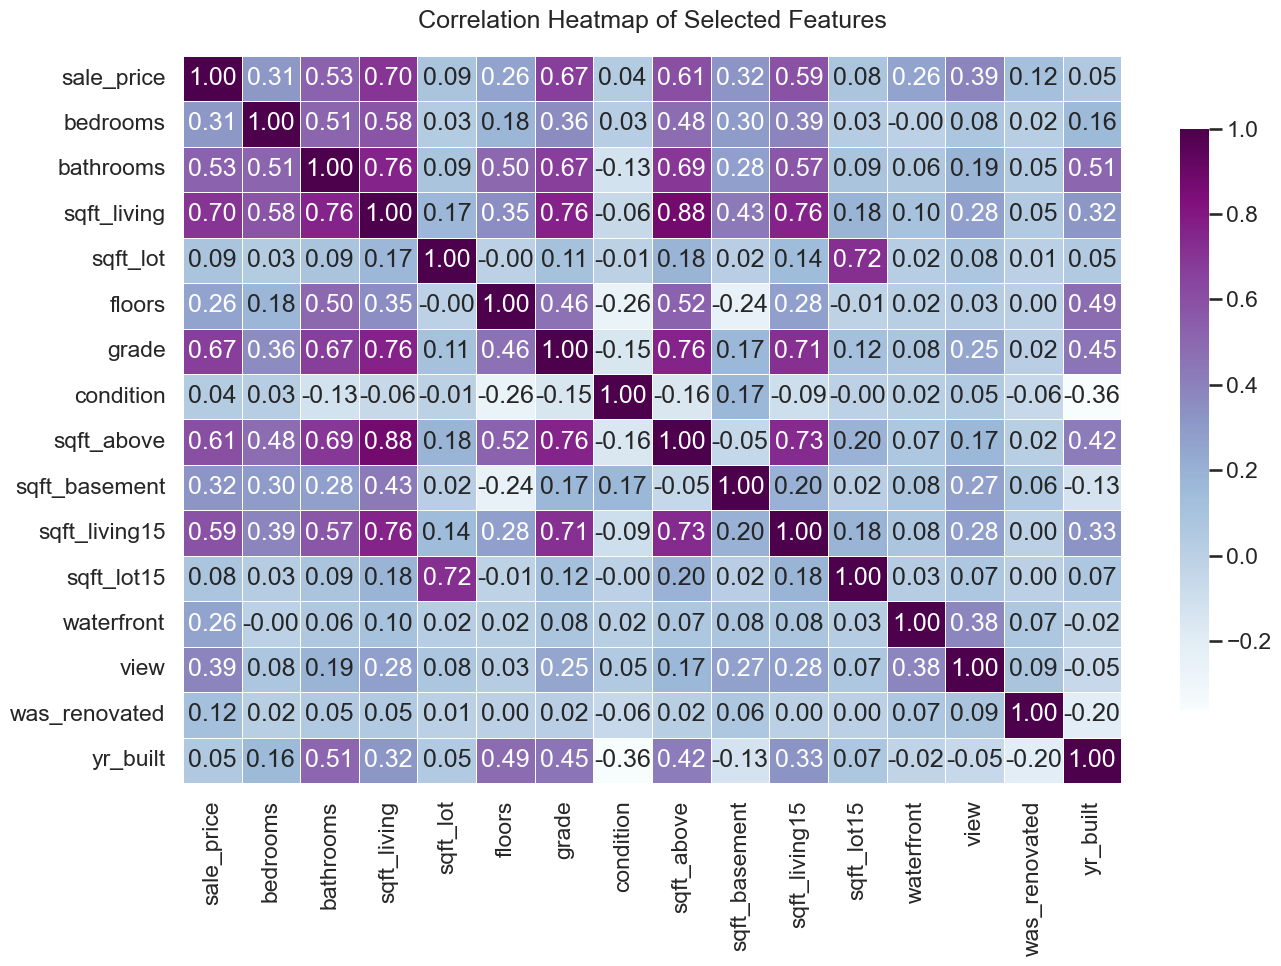

In [180]:
# Correlation heatmap for selected features (Stage 3.2)

heatmap_features = [
    'sale_price',
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'grade',
    'condition',
    'sqft_above',
    'sqft_basement',
    'sqft_living15',
    'sqft_lot15',
    'waterfront',
    'view',
    'was_renovated',
    'yr_built'
]

corr_matrix = df_housing[heatmap_features].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='BuPu',          # matches your purple theme
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Heatmap of Selected Features', pad=20)
plt.tight_layout()
plt.show()


**Heatmap Observation (Raw Sale Price)**
The heatmap shows that sale_price is most strongly correlated with size and quality features such as sqft_living, grade, bathrooms, and sqft_above. Several size-related variables are also highly correlated with each other, indicating potential multicollinearity. Since sale_price is right-skewed, the next step repeats this analysis using its log-transformed version for more reliable interpretation.

In [181]:
# Create log-transformed target for more stable relationship analysis

df_housing["log_sale_price"] = np.log1p(df_housing["sale_price"])
#df_housing[["sale_price", "log_sale_price"]].head()


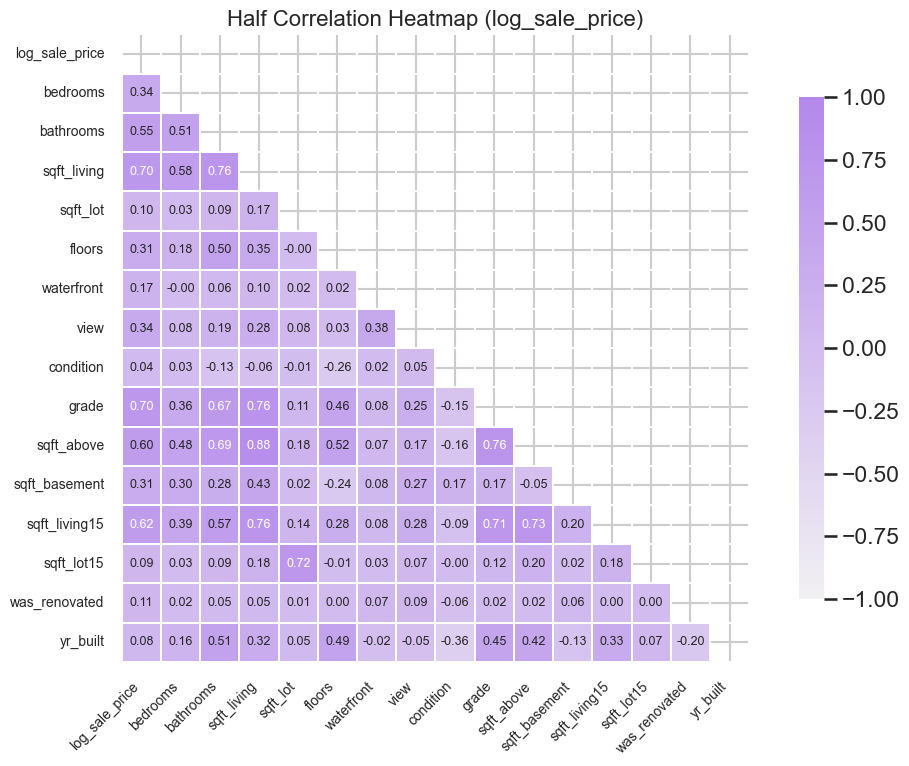

In [183]:
# Half correlation heatmap with a custom purple palette close to #B388EB

features_heatmap = [
    "log_sale_price",
    "bedrooms", "bathrooms",
    "sqft_living", "sqft_lot",
    "floors", "waterfront", "view",
    "condition", "grade",
    "sqft_above", "sqft_basement",
    "sqft_living15", "sqft_lot15",
    "was_renovated", "yr_built"
]

corr = df_housing[features_heatmap].corr(numeric_only=True)

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Custom purple palette close to #B388EB
purple_cmap = sns.light_palette("#B388EB", as_cmap=True)

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=purple_cmap,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor="white",
    square=True,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8}
)

plt.title("Half Correlation Heatmap (log_sale_price)", fontsize=16)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


In [184]:
strong_corr_signed = (
    corr['log_sale_price']
    .drop('log_sale_price')
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

strong_corr_signed[strong_corr_signed.abs() >= 0.65]


grade         0.704
sqft_living   0.695
Name: log_sale_price, dtype: float64

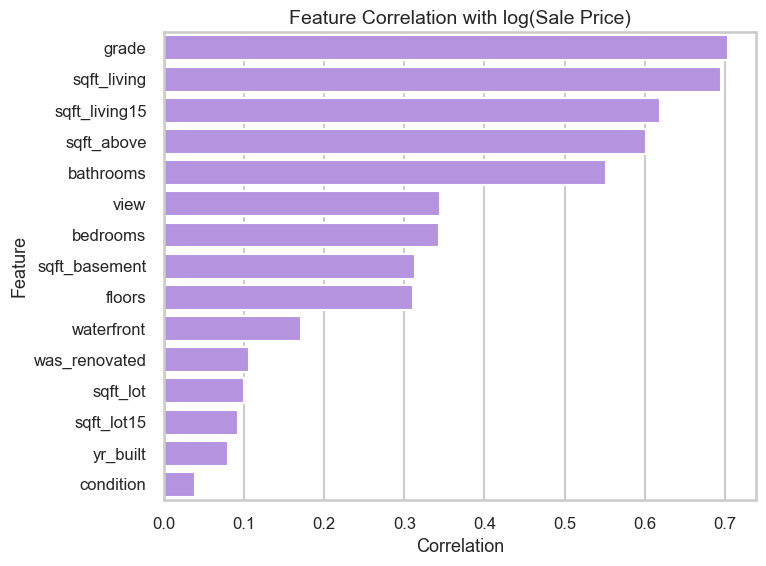

In [186]:
# Plot correlations with log_sale_price (ascending order)


# Prepare correlation series (ascending)
corr_log_price = (
    corr['log_sale_price']
    .drop('log_sale_price')
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(8, 6))

sns.barplot(
    x=corr_log_price.values,
    y=corr_log_price.index,
    color='#B388EB'
)

plt.title('Feature Correlation with log(Sale Price)', fontsize=14)
plt.xlabel('Correlation', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.axvline(0, color='gray', linewidth=1)
plt.tight_layout()
plt.show()



**Observation**

The correlation analysis using log_sale_price shows that property size and quality-related features have the strongest linear relationships with sale price.
In particular, grade, sqft_living, sqft_living15, and sqft_above exhibit the highest correlations, confirming that larger and higher-quality homes tend to command higher prices.

Moderate correlations are observed for bathrooms, view, bedrooms, and sqft_basement, suggesting these features contribute to price but with less explanatory power.
Features such as lot size, year built, renovation indicators, and condition show relatively weak correlations, indicating limited direct linear influence on price in isolation.

Overall, the results support focusing subsequent modeling efforts on size- and quality-driven features, while treating weaker predictors with caution or considering non-linear effects.

**Additional Observation (Multicollinearity Consideration)**

Since the main hypothesis of this analysis focuses on sale price, we prioritize features that show the strongest correlations with log_sale_price, namely grade, sqft_living, and sqft_living15.

At the same time, the correlation analysis reveals a high degree of inter-correlation between sqft_living and sqft_living15, indicating substantial redundancy. Moreover, sqft_living is also strongly correlated with grade, suggesting potential multicollinearity if these features are used together in downstream modeling.

Rather than making an immediate feature selection decision at this stage, both grade and sqft_living are carried forward to the next steps of the relationship analysis. In particular, their individual relationships with log_sale_price are examined in detail, and their interactions with renovation-related features are explored.

This comparative analysis allows us to assess which of these features better aligns with the study’s hypotheses and provides clearer, more interpretable insights for answering the research questions. The final decision on feature prioritization is therefore deferred to subsequent sections, based on empirical evidence rather than correlation alone.

#### 3.2.2 Relationship Between log(Sale Price) and Renovation Status

Since renovation is a direct and actionable decision variable for the client, we analyze it before exploring structural features such as living area or grade.
The client’s core question is whether renovating a property before selling leads to higher prices.
Therefore, we first examine the relationship between renovation status and log-transformed sale price to assess whether renovated homes systematically sell for more than non-renovated ones

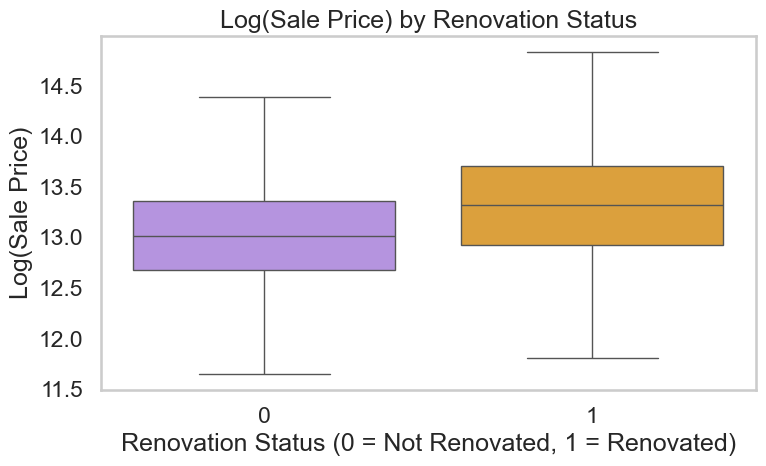

In [187]:
# Visualize the distribution of log-transformed sale price by renovation status

# Create log-transformed sale price if not already created
df_housing['log_sale_price'] = np.log(df_housing['sale_price'])

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_housing,
    x='was_renovated',
    y='log_sale_price',
    palette=['#B388EB', '#F5A623'],
    showfliers=False
)

plt.xlabel('Renovation Status (0 = Not Renovated, 1 = Renovated)')
plt.ylabel('Log(Sale Price)')
plt.title('Log(Sale Price) by Renovation Status')
plt.grid(False)
plt.tight_layout()
plt.show()


**Observation**
Renovated properties show a consistently higher median log sale price compared to non-renovated homes.
While the distributions overlap, renovation shifts the overall price level upward, indicating that renovation generally adds value.
This confirms renovation as a relevant decision factor for the client and justifies further investigation of how renovation interacts with other features such as living area and grade.

#### 3.2.3 Relationship Between log(Sale Price) and Living Area
In this step, we examine the relationship between living area (sqft_living) and sale price.
We first analyze the raw sale price to observe the original scale and potential non-linearity.
Then, we apply a logarithmic transformation to the sale price to assess whether the relationship becomes more linear and easier to interpret.
This comparison helps justify the use of log_sale_price in later modeling and hypothesis testing.

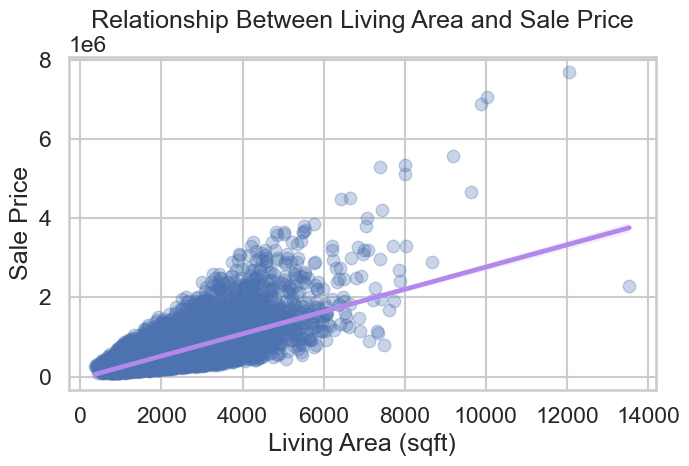

In [188]:
# Scatter plot of living area vs raw sale price with trend line

plt.figure(figsize=(7, 5))

sns.regplot(
    data=df_housing,
    x='sqft_living',
    y='sale_price',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': '#B388EB'}
)

plt.title('Relationship Between Living Area and Sale Price')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Sale Price')
plt.tight_layout()
plt.show()


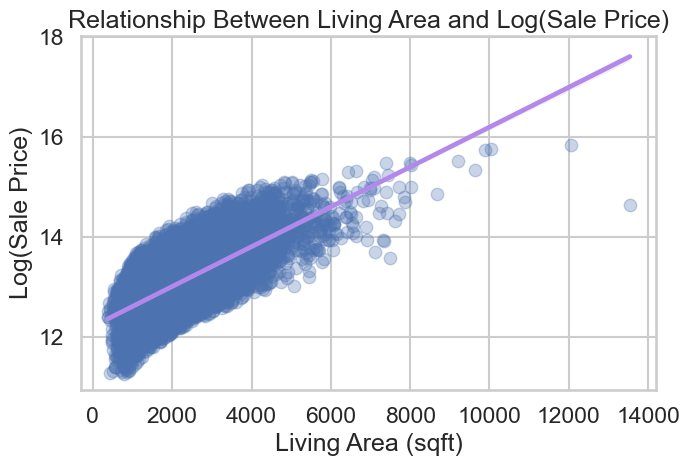

In [189]:
# Scatter plot of living area vs log-transformed sale price with trend line

# Create log-transformed sale price if not already created
df_housing['log_sale_price'] = np.log(df_housing['sale_price'])

plt.figure(figsize=(7, 5))

sns.regplot(
    data=df_housing,
    x='sqft_living',
    y='log_sale_price',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': '#B388EB'}
)
#plt.grid(False)
plt.title('Relationship Between Living Area and Log(Sale Price)')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Log(Sale Price)')
plt.tight_layout()
plt.show()



**Observation**

In the raw scale, the relationship between living area and sale price shows a positive trend, but it is noticeably influenced by extreme high-price outliers, which pull the regression line downward for the majority of observations.

After applying a log transformation to sale price, the relationship becomes more linear and stable. The influence of extreme values is reduced, the variance is more uniform across living area sizes, and the trend line better represents the central pattern of the data.

This confirms that using log(Sale Price) is more appropriate for modeling and hypothesis-driven analysis involving living area.

Sale price shows a clear positive relationship with living area: larger houses tend to sell for higher prices.
However, the relationship is not perfectly linear, and a small number of extreme observations deviate from the
general trend, indicating potential outliers that require further inspection.


In [190]:
# Inspect very large houses with relatively low prices
df_housing.loc[
    df_housing['sqft_living'] >= 12000,
    ['sqft_living', 'bedrooms', 'bathrooms', 'floors',
     'sqft_lot', 'grade', 'condition', 'yr_built',
     'yr_renovated', 'sale_price', 'zipcode']
]


,sqft_living,bedrooms,bathrooms,floors,sqft_lot,grade,condition,yr_built,yr_renovated,sale_price,zipcode
7245,12050.000,6.000,8.000,2.500,27600.000,13,4,1910,1987,7700000.000,98102
12764,13540.000,7.000,8.000,3.000,307752.000,12,3,1999,0,2280000.000,98053


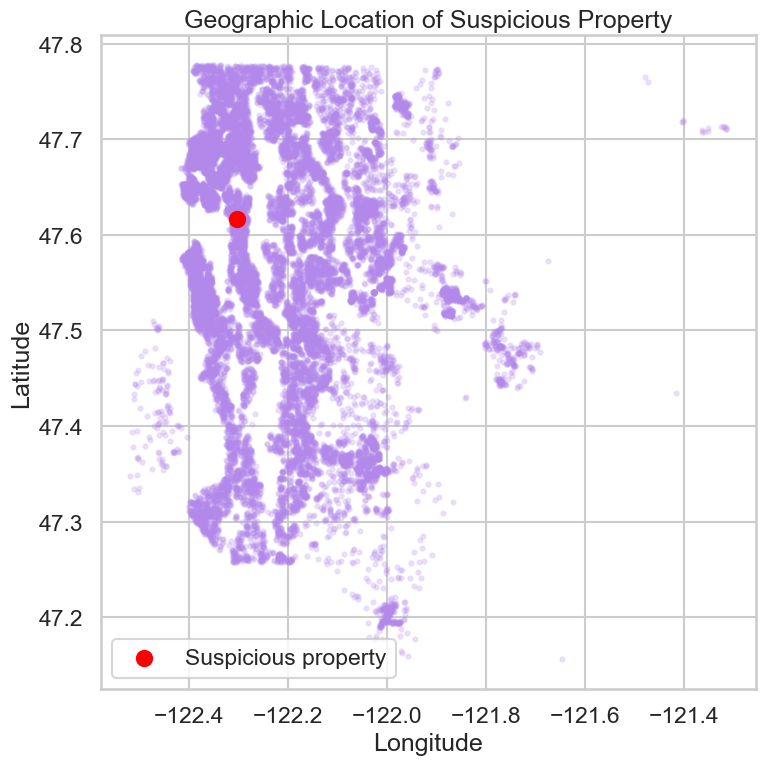

In [191]:
# Select suspicious property (very large living area with low price)
suspicious_house = df_housing.loc[df_housing['sale_id'] == 12764]

# Plot all houses on the map
plt.figure(figsize=(8, 8))
plt.scatter(
    df_housing['long'],
    df_housing['lat'],
    alpha=0.2,
    s=10,
    color='#B388EB'
)

# Highlight suspicious house
plt.scatter(
    suspicious_house['long'],
    suspicious_house['lat'],
    color='red',
    s=120,
    label='Suspicious property'
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Location of Suspicious Property')
plt.legend()
plt.tight_layout()
plt.show()


**Observation**
During the analysis of the relationship between living area and sale price, a small number of properties with extremely large living areas (>12,000 sqft) were identified. One of these properties exhibited a notably low sale price relative to its size, deviating clearly from the overall positive price–size trend.

To further investigate this anomaly, the property was highlighted on the geographic (latitude–longitude) map. Despite its unusually low price, the property is located within a central and highly active urban area rather than a peripheral or low-demand region.

This spatial context suggests that the atypical pricing cannot be readily explained by location alone and may be driven by other unobserved factors (e.g. property condition, special sale circumstances, data quality issues). Consequently, this observation is flagged as suspicious and will be revisited during the data cleaning phase rather than being removed at this stage.


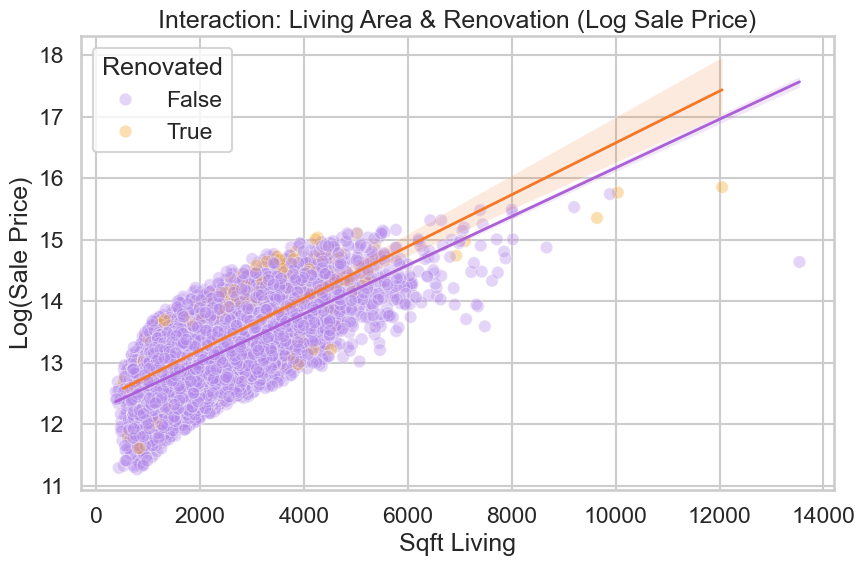

In [192]:
# Interaction between living area and renovation status (log sale price)

# Ensure required columns exist
df_housing['log_sale_price'] = np.log(df_housing['sale_price'])
df_housing['is_renovated'] = df_housing['yr_renovated'] > 0

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_housing,
    x='sqft_living',
    y='log_sale_price',
    hue='is_renovated',
    alpha=0.35,
    palette={False: '#B388EB', True: '#F5A623'}
)

sns.regplot(
    data=df_housing[df_housing['is_renovated'] == False],
    x='sqft_living',
    y='log_sale_price',
    scatter=False,
    color='#AC60D6',
    line_kws={'linewidth': 2}
)

sns.regplot(
    data=df_housing[df_housing['is_renovated'] == True],
    x='sqft_living',
    y='log_sale_price',
    scatter=False,
    color='#F57723',
    line_kws={'linewidth': 2}
)

plt.title('Interaction: Living Area & Renovation (Log Sale Price)')
plt.xlabel('Sqft Living')
plt.ylabel('Log(Sale Price)')
plt.legend(title='Renovated')
plt.tight_layout()
plt.show()


**Observation**
Living area shows a strong and clear positive relationship with sale price, confirming that property size is one of the primary drivers of housing value. Renovation also has a generally positive effect on price, as renovated properties tend to sell for slightly higher prices compared to non-renovated ones.

However, when examining the interaction between renovation and living area, the effect of renovation appears limited. The regression lines for renovated and non-renovated houses are very similar and largely parallel, indicating that renovation does not significantly amplify the impact of living area on price. For larger houses, renovation leads to only a modest additional price increase rather than a substantial premium.

This suggests that while renovation can add value, it is not a strong differentiating factor when considered together with living area. Since living area already captures much of the price variation, the marginal contribution of renovation in this context remains small.

For this reason, the next step of the analysis focuses on grade, to investigate whether renovation has a stronger and more meaningful impact on perceived quality and construction standard, and whether grade better captures the value added by renovation than living area alone.

#### 3.2.4 Relationship Between log(Sale Price) and Grade
In this step, we examine the relationship between house quality (grade) and the logarithm of sale price. Since grade shows a strong correlation with price, this analysis helps validate whether higher construction and design quality consistently translates into higher property values.

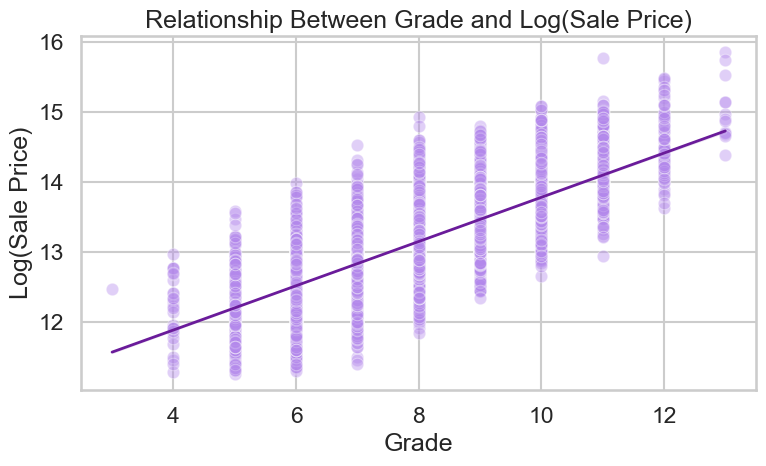

In [193]:
# Scatter plot of grade vs log(Sale Price) with trend line

# Ensure log-transformed target exists
df_housing['log_sale_price'] = np.log(df_housing['sale_price'])

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_housing,
    x='grade',
    y='log_sale_price',
    alpha=0.4,
    color='#B388EB'
)

sns.regplot(
    data=df_housing,
    x='grade',
    y='log_sale_price',
    scatter=False,
    color='#6A1B9A',
    line_kws={'linewidth': 2}
)

plt.title('Relationship Between Grade and Log(Sale Price)')
plt.xlabel('Grade')
plt.ylabel('Log(Sale Price)')
plt.tight_layout()
plt.show()


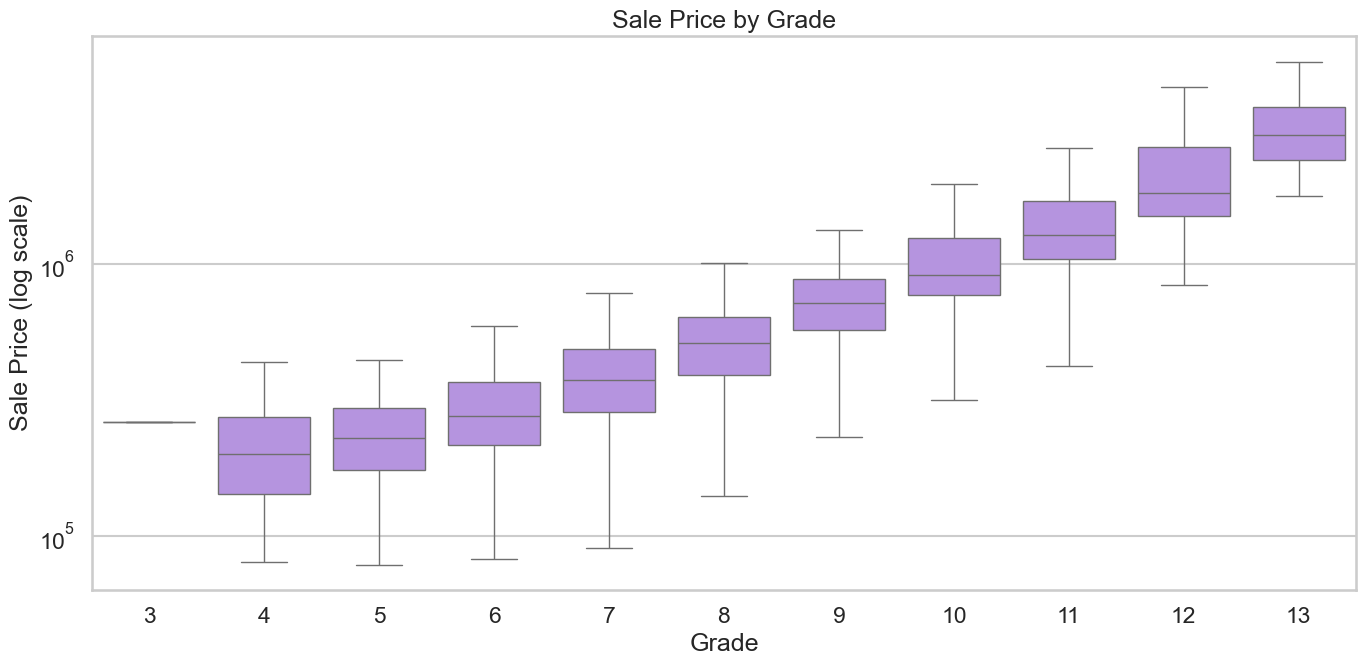

In [194]:
# Boxplot of sale price by grade to examine the overall price–quality relationship

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_housing,
    x='grade',
    y='sale_price',
    color='#B388EB',
    showfliers=False
)

plt.yscale('log')
plt.title('Sale Price by Grade')
plt.xlabel('Grade')
plt.ylabel('Sale Price (log scale)')

plt.tight_layout()
plt.show()


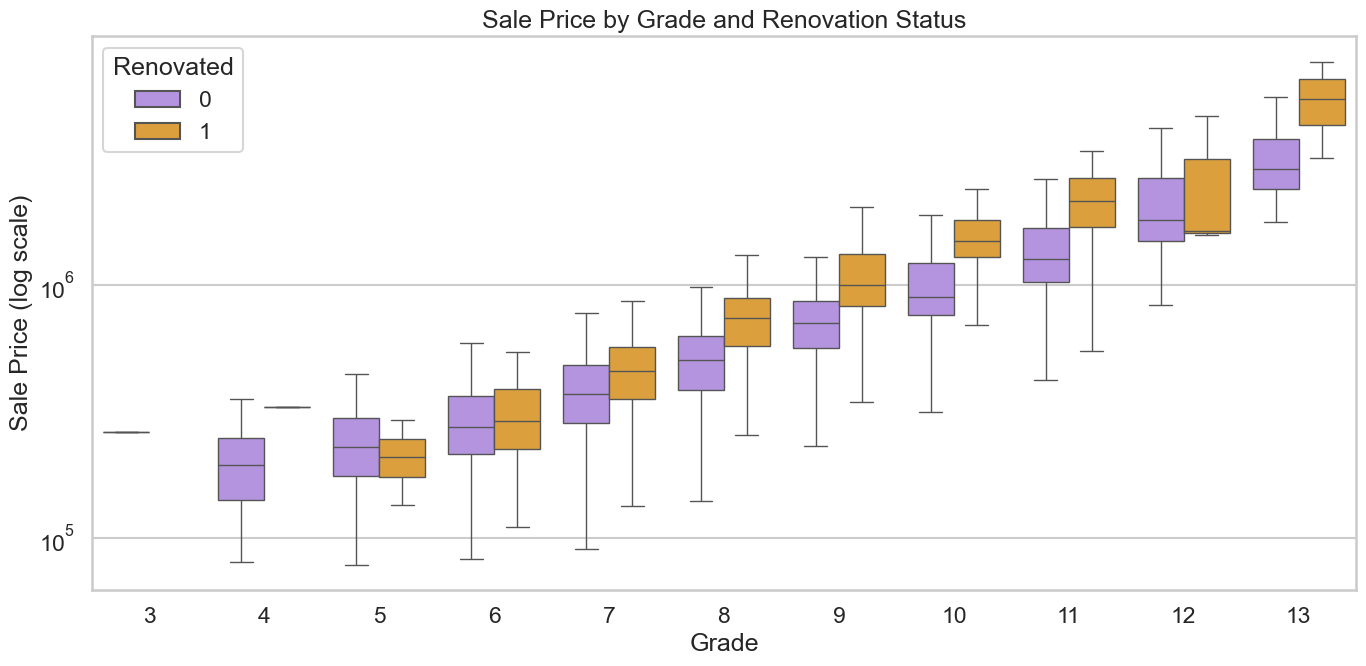

In [195]:
# Boxplot of sale price by grade, split by renovation status to assess renovation impact

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_housing,
    x='grade',
    y='sale_price',
    hue='was_renovated',
    palette=['#B388EB', '#F5A623'],
    showfliers=False
)

plt.yscale('log')
plt.title('Sale Price by Grade and Renovation Status')
plt.xlabel('Grade')
plt.ylabel('Sale Price (log scale)')
plt.legend(title='Renovated')

plt.tight_layout()
plt.show()


**Observation**
The results confirm that grade has a strong and consistent positive relationship with sale price: as grade increases, the sale price rises steadily across all levels. This reinforces grade as one of the most influential structural quality indicators in the dataset.

When renovation status is added, an additional pattern becomes visible. While renovation does not dramatically change prices within every grade, it creates a clearer price separation at medium to higher grade levels. For these grades, renovated properties tend to achieve noticeably higher prices compared to non-renovated ones.

In contrast, the interaction between renovation and living area showed only a limited effect: larger homes benefit slightly from renovation, but the overall price difference remains modest. This suggests that renovation impacts perceived quality (grade) more strongly than sheer size (square footage).

From a decision-making perspective, this implies that grade is more informative than living area for explaining price differences, especially when combined with renovation. Therefore, for the client’s hypothesis and pricing strategy, focusing on improving or targeting grade-related quality attributes is likely more effective than relying on increases in square footage alone.

#### 3.2.5 Location Effect Zipcode vs log(Sale Price)
Location is a major driver of housing prices. Zipcode acts as a proxy for neighborhood and local amenities.
To understand the location effect, we compare the distribution of log(Sale Price) across zipcodes (focusing on the most frequent zipcodes to keep the plot readable).

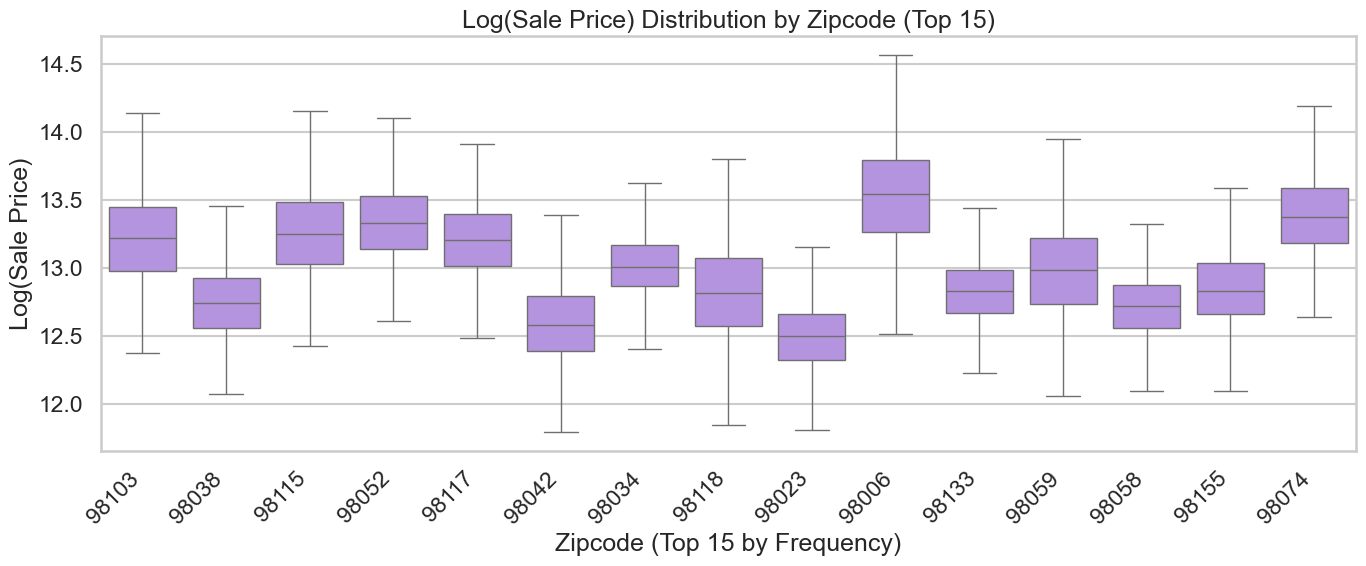

In [196]:
# Compare log sale price across the most frequent zipcodes

# Ensure log_sale_price exists
df_housing['log_sale_price'] = np.log(df_housing['sale_price'])

# Select top N zipcodes by frequency to keep the plot readable
top_n = 15
top_zipcodes = df_housing['zipcode'].value_counts().head(top_n).index

df_zip = df_housing[df_housing['zipcode'].isin(top_zipcodes)].copy()

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df_zip,
    x='zipcode',
    y='log_sale_price',
    order=top_zipcodes,
    palette=['#B388EB'] * len(top_zipcodes),
    showfliers=False
)

plt.xlabel('Zipcode (Top 15 by Frequency)')
plt.ylabel('Log(Sale Price)')
plt.title('Log(Sale Price) Distribution by Zipcode (Top 15)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


Observation: The distribution of sale prices varies substantially across zipcodes.
While many zipcodes share overlapping price ranges, a clear separation emerges in terms of median sale prices, with some zipcodes consistently showing higher central values and wider upper tails, and others remaining concentrated at lower price levels.
This heterogeneity suggests that zipcode captures meaningful neighborhood-level differences in housing prices.
Therefore, instead of treating zipcodes individually, it is reasonable to group them into broader price-based area categories (low, mid, high) to simplify analysis and enable clearer comparison in subsequent EDA steps.

In [197]:
# Calculate median sale price per zipcode
zipcode_median_price = (
    df_housing
    .groupby('zipcode')['sale_price']
    .median()
)
# zipcode_median_price.sort_values(ascending=False)   


In [198]:
# Create price-based zipcode groups using quantiles
zipcode_price_group = pd.qcut(
    zipcode_median_price,
    q=3,
    labels=['Low-price area', 'Mid-price area', 'High-price area']
)
# zipcode_price_group.sort_values(ascending=False)

In [199]:
# Map zipcode price group back to main dataframe
df_housing['zipcode_price_group'] = df_housing['zipcode'].map(zipcode_price_group)
df_housing.head(5)

,house_id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_lot15,sale_id,sale_date,sale_price,was_renovated,sale_year,sale_month,log_sale_price,is_renovated,zipcode_price_group
0,7129300520,3.000,1.000,1180.000,5650.000,1.000,0.000,0.000,3,7,...,5650.000,1,2014-10-13,221900.000,0,2014,October,12.310,False,Low-price area
1,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,3,7,...,7639.000,2,2014-12-09,538000.000,1,2014,December,13.196,True,Mid-price area
2,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,3,6,...,8062.000,3,2015-02-25,180000.000,0,2015,February,12.101,False,Mid-price area
3,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,5,7,...,5000.000,4,2014-12-09,604000.000,0,2014,December,13.311,False,Mid-price area
4,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,3,8,...,7503.000,5,2015-02-18,510000.000,0,2015,February,13.142,False,High-price area


In [200]:
# Check distribution of observations per group
df_housing['zipcode_price_group'].value_counts()

zipcode_price_group
Low-price area     7795
High-price area    7011
Mid-price area     6791
Name: count, dtype: int64

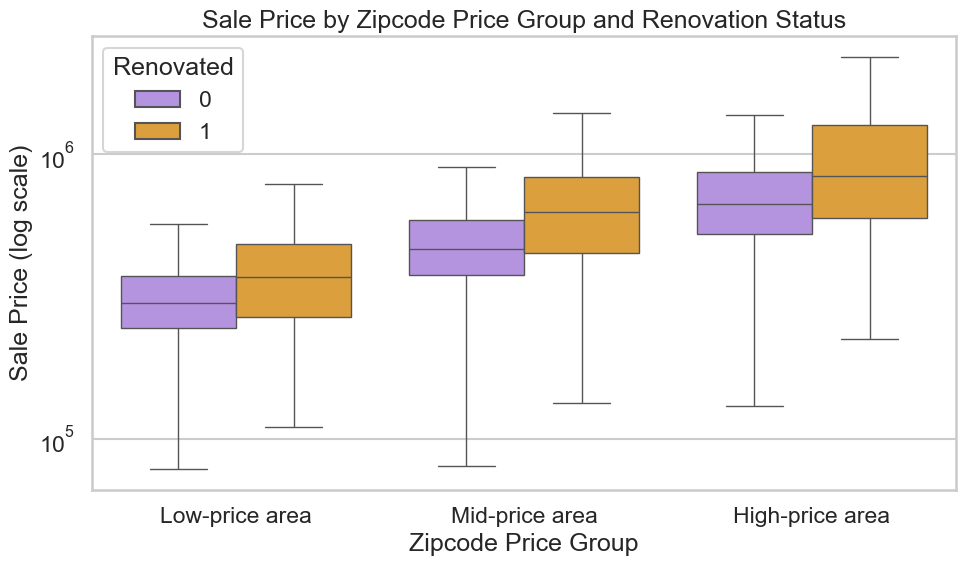

In [201]:
# Boxplot of sale price by zipcode price group, split by renovation status


sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_housing,
    x='zipcode_price_group',
    y='sale_price',
    hue='was_renovated',
    palette={
        False: '#B388EB',   # Not renovated
        True: '#F5A623'     # Renovated
    },
    showfliers=False
)

plt.yscale('log')
plt.title('Sale Price by Zipcode Price Group and Renovation Status')
plt.xlabel('Zipcode Price Group')
plt.ylabel('Sale Price (log scale)')
plt.legend(title='Renovated')

plt.tight_layout()
plt.show()


**Observation**
The analysis shows that location, captured through zipcode-based price groups, has a strong relationship with sale price.
By grouping zipcodes into low-price, mid-price, and high-price areas based on historical median prices, a clear separation in log-transformed sale prices emerges across these groups.

Properties located in high-price areas consistently achieve higher sale prices, while homes in low-price areas remain significantly cheaper, even when controlling for other structural features. This indicates that location acts as a structural price driver rather than a noise variable.

From a decision-making perspective, this result is especially relevant for the client:
while renovations or changes in living area can influence price at the property level, the underlying price level of the area sets a strong baseline that cannot be fully compensated by property-level improvements alone.

Therefore, zipcode (expressed through price-based area groups) is confirmed as a key contextual feature for explaining price differences and should be retained in further modeling and decision analysis.

### 3.3 Decision-Oriented Analysis (Client-Focused Insights)
In this section, we move beyond pairwise relationships and combine multiple features to derive actionable insights.
The goal is not only to understand how individual variables relate to sale price, but to evaluate how combinations of location, grade, and renovation status influence pricing outcomes and support client decision-making.

#### 3.3.1 Combined Effect of Grade, Renovation, and Location on Sale Price

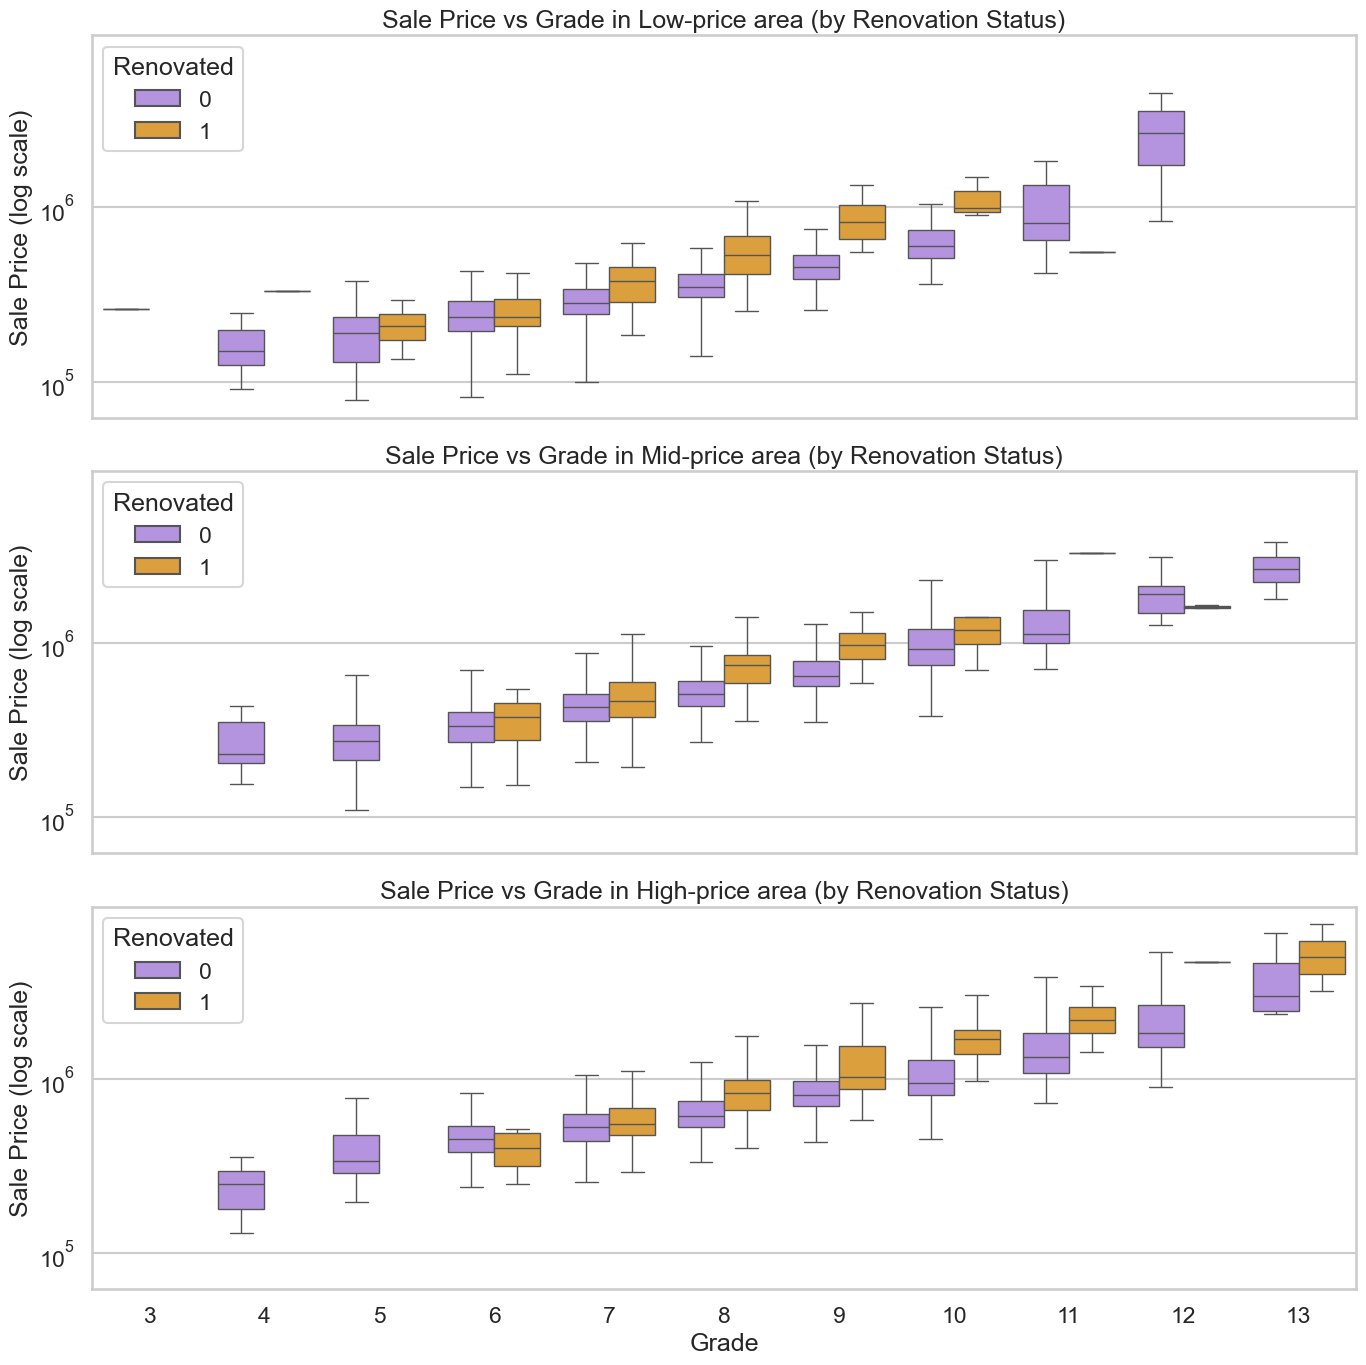

In [202]:
# Plot sale price vs grade within each zipcode price group (low/mid/high), split by renovation status

group_order = ["Low-price area", "Mid-price area", "High-price area"]
hue_order = [0, 1]  # Renovated: 0 = No, 1 = Yes

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 14), sharex=True, sharey=True)

for ax, grp in zip(axes, group_order):
    subset = df_housing[df_housing["zipcode_price_group"] == grp]

    sns.boxplot(
        data=subset,
        x="grade",
        y="sale_price",
        hue="was_renovated",
        hue_order=hue_order,
        ax=ax,
        showfliers=False,
           palette={
        False: '#B388EB',   # Not renovated
        True: '#F5A623'     # Renovated
    }
    )

    ax.set_yscale("log")
    ax.set_title(f"Sale Price vs Grade in {grp} (by Renovation Status)")
    ax.set_xlabel("Grade")
    ax.set_ylabel("Sale Price (log scale)")
    ax.legend(title="Renovated", loc="upper left")

plt.tight_layout()
plt.show()


**Observation** Combined Effect of Grade, Renovation, and Location

Across all price areas, grade shows a strong and consistent positive relationship with sale price, confirming it as one of the most influential drivers of property value. As grade increases, median sale prices rise steadily regardless of renovation status.

When renovation is considered jointly with grade, its effect becomes context-dependent rather than uniform:

Low-price areas:
Renovation does not consistently lead to higher sale prices for lower grades. For grades below approximately 8, the price distributions of renovated and non-renovated homes largely overlap, suggesting limited or no return on renovation investment. Only at higher grades does renovation begin to show a clearer price uplift.

Mid-price areas:
This segment exhibits the most pronounced and reliable renovation effect. For mid-to-high grades (roughly grades 8–10), renovated properties tend to achieve noticeably higher sale prices with reduced overlap between distributions. This indicates a favorable balance between renovation cost and potential price uplift, making mid-price areas particularly attractive for renovation-driven strategies.

High-price areas:
Sale prices increase strongly with grade regardless of renovation status, reinforcing grade as the dominant factor. Although renovated homes often sell for higher absolute prices, the incremental benefit of renovation is less distinct and more variable at higher grades. This suggests higher risk and diminishing marginal returns for renovation in premium markets.

Overall conclusion:
Grade plays a more decisive role in explaining sale price than renovation alone. Renovation is most effective when combined with mid-to-high grades, and its payoff varies substantially by price area. Therefore, renovation decisions should be grade- and location-specific, rather than applied uniformly across the market.

#### 3.3.2 Renovation Uplift by Grade and Price Area (Median-Based)

In [203]:


# --- 1) Median sale price per zipcode ---
zipcode_median_price = (
    df_housing
    .groupby('zipcode')['sale_price']
    .median()
)

# --- 2) Quantile-based groups (q=3) on zipcode medians ---
qcat = pd.qcut(
    zipcode_median_price,
    q=3,
    labels=['Low-price area', 'Mid-price area', 'High-price area'],
    duplicates='drop'
)

# IMPORTANT: build a proper mapping Series (zipcode -> group label)
zipcode_to_group = pd.Series(qcat, index=zipcode_median_price.index)

# --- 3) Map back to main dataframe ---
df_housing['zipcode_price_group'] = df_housing['zipcode'].map(zipcode_to_group)

# --- 4) Build REAL numeric ranges for the legend (based on zipcode medians) ---
ranges = (
    pd.DataFrame({
        'zipcode': zipcode_median_price.index,
        'zip_median': zipcode_median_price.values,
        'zipcode_price_group': zipcode_to_group.values
    })
    .groupby('zipcode_price_group')['zip_median']
    .agg(group_min='min', group_max='max', n_zipcodes='count')
    .reset_index()
)

# --- 5) Legend labels with real ranges ---
ranges['legend_label'] = (
    ranges['zipcode_price_group'].astype(str)
    + " (zip median: $"
    + ranges['group_min'].round(0).map(lambda x: f"{x:,.0f}")
    + "–$"
    + ranges['group_max'].round(0).map(lambda x: f"{x:,.0f}")
    + ")"
)

ranges



,zipcode_price_group,group_min,group_max,n_zipcodes,legend_label
0,Low-price area,235000.000,375000.000,25,"Low-price area (zip median: $235,000–$375,000)"
1,Mid-price area,380000.000,554000.000,22,"Mid-price area (zip median: $380,000–$554,000)"
2,High-price area,555000.000,1895000.000,23,"High-price area (zip median: $555,000–$1,895,000)"


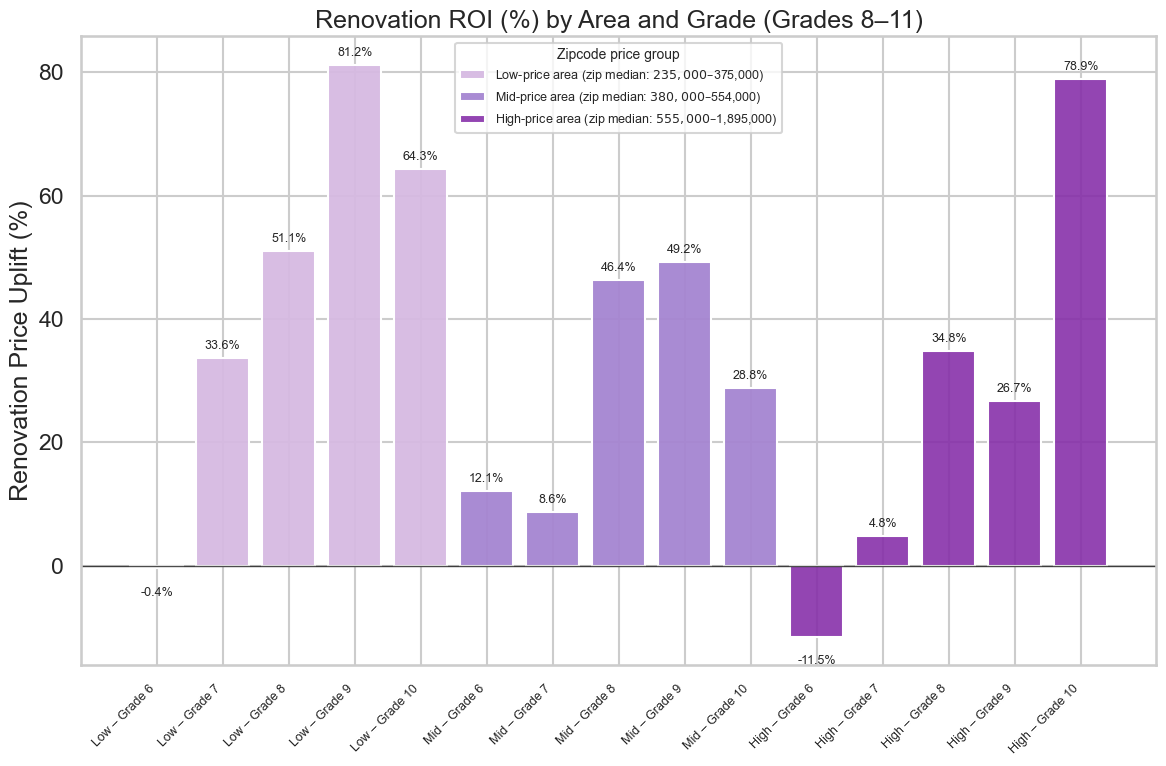

In [204]:

# ============================================================
# Renovation ROI (%) by Area and Grade (Grades 8–11)
# FULL & FIXED VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 0) Required mappings (SAFE defaults)
# ------------------------------------------------------------

legend_map = (
    ranges
    .set_index("zipcode_price_group")["legend_label"]
    .to_dict()
)

area_order = ["Low-price area", "Mid-price area", "High-price area"]

area_colors = {
    "Low-price area": "#D6B9E2F0",
    "Mid-price area": "#A585D1F2",
    "High-price area": "#852DA8E2"
}

legend_map = {
    "Low-price area": "Low-price area",
    "Mid-price area": "Mid-price area",
    "High-price area": "High-price area"
}

# ------------------------------------------------------------
# 1) Prepare data for Renovation ROI (Grades 8–11)
# ------------------------------------------------------------

df_roi = df_housing[df_housing["grade"].between(6, 10)].copy()

roi_summary = (
    df_roi
    .groupby(["zipcode_price_group", "grade", "was_renovated"])["sale_price"]
    .median()
    .unstack()  # columns: 0 = not renovated, 1 = renovated
)

# Safe ROI calculation
roi_summary["pct_uplift"] = (
    (roi_summary[1] - roi_summary[0]) / roi_summary[0]
).replace([np.inf, -np.inf], np.nan) * 100

# ------------------------------------------------------------
# 2) Final dataframe for plotting
# ------------------------------------------------------------

plot_df = (
    roi_summary
    .reset_index()
    .dropna(subset=["pct_uplift"])
)

plot_df["zipcode_price_group"] = pd.Categorical(
    plot_df["zipcode_price_group"],
    categories=area_order,
    ordered=True
)

plot_df["label"] = (
    plot_df["zipcode_price_group"].astype(str).str.replace("-price area", "")
    + " – Grade "
    + plot_df["grade"].astype(str)
)

plot_df = plot_df.sort_values(
    ["zipcode_price_group", "grade"]
)

legend_map = (
    ranges
    .set_index("zipcode_price_group")["legend_label"]
    .to_dict()
)
# ------------------------------------------------------------
# 3) Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(plot_df))
bar_colors = [
    area_colors[a] for a in plot_df["zipcode_price_group"]
]

ax.bar(x, plot_df["pct_uplift"], color=bar_colors)

# Zero reference line
ax.axhline(0, linewidth=1, color="black", alpha=0.7)

# Axes
#ax.grid(False)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Renovation Price Uplift (%)")
ax.set_title("Renovation ROI (%) by Area and Grade (Grades 8–11)")

# ------------------------------------------------------------
# Add percentage labels on top of bars
# ------------------------------------------------------------
for i, value in enumerate(plot_df["pct_uplift"]):
    if value >= 0:
        ax.text(
            i,
            value + 1,                 # little offset above bar
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )
    else:
        ax.text(
            i,
            value - 3,                 # offset below bar for negative values
            f"{value:.1f}%",
            ha="center",
            va="top",
            fontsize=9
        )


# Legend
legend_handles = [
    Patch(facecolor=area_colors[a], label=legend_map[a])
    for a in area_order
]

ax.legend(
    handles=legend_handles,
    title="Zipcode price group",
    fontsize=9,
    title_fontsize=10,
    loc="upper center",
    frameon=True
)

plt.tight_layout()
plt.show()


In [205]:
# ------------------------------------------------------------
# Build pivot_prices for uplift table (SAFE & COMPLETE)
# ------------------------------------------------------------

pivot_prices = (
    df_housing
    .groupby(["zipcode_price_group", "grade", "was_renovated"])["sale_price"]
    .median()
    .unstack()
    .rename(columns={
        0: "median_no_renovation",
        1: "median_renovated"
    })
    .reset_index()
)

# Absolute uplift
pivot_prices["abs_uplift"] = (
    pivot_prices["median_renovated"] - pivot_prices["median_no_renovation"]
)

# Percent uplift (safe)
pivot_prices["pct_uplift"] = (
    pivot_prices["abs_uplift"] / pivot_prices["median_no_renovation"]
).replace([np.inf, -np.inf], np.nan) * 100


In [206]:
# ============================================================
# Styled uplift table (NO NaN + custom purple colors)
# ============================================================

import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------------------------
# 1) Remove NaN rows (keep only valid comparisons)
# ------------------------------------------------------------

pivot_prices = pivot_prices.dropna(
    subset=["median_no_renovation", "median_renovated", "abs_uplift", "pct_uplift"]
)

# ------------------------------------------------------------
# 2) Custom purple colormaps (your exact colors)
# ------------------------------------------------------------

purple_pct_cmap = LinearSegmentedColormap.from_list(
    "purple_pct",
    ["#F3EAF8", "#A585D1F2", "#852DA8E2"]
)

purple_abs_cmap = LinearSegmentedColormap.from_list(
    "purple_abs",
    ["#F7F1FB", "#B489C6EF", "#6F218EE1"]
)

# ------------------------------------------------------------
# 3) Styled table (absolute + percent uplift)
# ------------------------------------------------------------

display_cols = [
    "zipcode_price_group", "grade",
    "median_no_renovation", "median_renovated",
    "abs_uplift", "pct_uplift"
]

styled = (
    pivot_prices[display_cols]
    .sort_values(["zipcode_price_group", "grade"])
    .style
    .background_gradient(subset=["pct_uplift"], cmap=purple_pct_cmap)
    .background_gradient(subset=["abs_uplift"], cmap=purple_abs_cmap)
    .format({
        "median_no_renovation": "${:,.0f}",
        "median_renovated": "${:,.0f}",
        "abs_uplift": "${:,.0f}",
        "pct_uplift": "{:.1f}%"
    })
)

styled


was_renovated,zipcode_price_group,grade,median_no_renovation,median_renovated,abs_uplift,pct_uplift
1,Low-price area,4,"$150,500","$330,000","$179,500",119.3%
2,Low-price area,5,"$189,950","$208,000","$18,050",9.5%
3,Low-price area,6,"$235,000","$234,000","$-1,000",-0.4%
4,Low-price area,7,"$282,000","$376,875","$94,875",33.6%
5,Low-price area,8,"$350,000","$528,750","$178,750",51.1%
6,Low-price area,9,"$452,500","$820,000","$367,500",81.2%
7,Low-price area,10,"$600,000","$986,000","$386,000",64.3%
8,Low-price area,11,"$810,000","$550,000","$-260,000",-32.1%
14,Mid-price area,6,"$335,000","$375,475","$40,475",12.1%
15,Mid-price area,7,"$428,000","$465,000","$37,000",8.6%


**Observation**

The renovation uplift is not uniform across locations and grades.
The highest renovation ROI is observed in mid-price areas, especially for grades 9–11, where renovation leads to a strong and consistent price uplift. This suggests that in mid-price neighborhoods, renovation is most likely to translate into meaningful resale gains.

In low-price areas, renovation shows mixed results. While mid-grades (8–10) can benefit moderately, some high-grade cases even exhibit negative uplift, indicating that renovation does not necessarily pay off and may increase costs without proportional resale value.

In high-price areas, renovation generally leads to positive price increases, but the percentage uplift is smaller compared to mid-price areas. This suggests that while absolute prices are high, renovation contributes less marginal value relative to the already high baseline prices.

Overall, the results indicate that renovation ROI depends strongly on both location and grade, with mid-price areas and mid-to-high grades offering the most attractive risk-return profile.

In [207]:
mid_grade11_reno = df_housing[
    (df_housing["zipcode_price_group"] == "Mid-price area") &
    (df_housing["grade"] == 11) &
    (df_housing["was_renovated"] == 1)
]

mid_grade11_reno.shape
mid_grade11_reno.head()


,house_id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_lot15,sale_id,sale_date,sale_price,was_renovated,sale_year,sale_month,log_sale_price,is_renovated,zipcode_price_group
18185,3625059152,3.000,3.250,4220.000,41300.000,1.000,1.000,4.000,4,11,...,30401.000,18186,2014-12-30,3300000.000,1,2014,December,15.009,True,Mid-price area


#### 3.3.3 Renovation ROI by Grade, Location, and Investment Budget

In [209]:
# ============================================================
# ROI Calculation Based on Median Prices (FIXED)
# ============================================================

# Focus on relevant grades
GRADES_FOCUS = [6,7,8, 9, 10]
roi_base = df_housing.loc[df_housing["grade"].isin(GRADES_FOCUS)].copy()

# Median sale price by area, grade, and renovation status
pivot_prices = (
    roi_base
    .groupby(["zipcode_price_group", "grade", "was_renovated"])["sale_price"]
    .median()
    .unstack("was_renovated")
    .rename(columns={
        0: "median_no_renovation",
        1: "median_renovated"
    })
    .reset_index()
)

# Compute absolute and percentage uplift
pivot_prices["abs_uplift"] = (
    pivot_prices["median_renovated"] - pivot_prices["median_no_renovation"]
)

pivot_prices["pct_uplift"] = (
    pivot_prices["abs_uplift"] / pivot_prices["median_no_renovation"]
) * 100

# Keep only rows where both renovated and non-renovated exist
pivot_prices = pivot_prices.dropna(
    subset=["median_no_renovation", "median_renovated"]
).copy()

# ------------------------------------------------------------
# Investment buckets based on baseline (no-renovation) price
# ------------------------------------------------------------

bins = [-np.inf, 500_000, 700_000, 1_000_000, np.inf]
labels = [
    "Low budget (<500k)",
    "Lower-mid (500k–700k)",
    "Upper-mid (700k–1M)",
    "High budget (>1M)"
]

pivot_prices["investment_bucket"] = pd.cut(
    pivot_prices["median_no_renovation"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# ------------------------------------------------------------
# Pretty table (display)
# ------------------------------------------------------------

display(
    pivot_prices[[
        "zipcode_price_group", "grade",
        "median_no_renovation", "median_renovated",
        "abs_uplift", "pct_uplift",
        "investment_bucket"
    ]]
    .sort_values(["zipcode_price_group", "grade"])
    .style
    .format({
        "median_no_renovation": "${:,.0f}",
        "median_renovated": "${:,.0f}",
        "abs_uplift": "${:,.0f}",
        "pct_uplift": "{:.1f}%"
    })
    .background_gradient(subset=["pct_uplift"], cmap="RdYlGn")
)


was_renovated,zipcode_price_group,grade,median_no_renovation,median_renovated,abs_uplift,pct_uplift,investment_bucket
0,Low-price area,6,"$235,000","$234,000","$-1,000",-0.4%,Low budget (<500k)
1,Low-price area,7,"$282,000","$376,875","$94,875",33.6%,Low budget (<500k)
2,Low-price area,8,"$350,000","$528,750","$178,750",51.1%,Low budget (<500k)
3,Low-price area,9,"$452,500","$820,000","$367,500",81.2%,Low budget (<500k)
4,Low-price area,10,"$600,000","$986,000","$386,000",64.3%,Lower-mid (500k–700k)
5,Mid-price area,6,"$335,000","$375,475","$40,475",12.1%,Low budget (<500k)
6,Mid-price area,7,"$428,000","$465,000","$37,000",8.6%,Low budget (<500k)
7,Mid-price area,8,"$510,000","$746,500","$236,500",46.4%,Lower-mid (500k–700k)
8,Mid-price area,9,"$650,000","$970,000","$320,000",49.2%,Lower-mid (500k–700k)
9,Mid-price area,10,"$927,500","$1,195,000","$267,500",28.8%,Upper-mid (700k–1M)


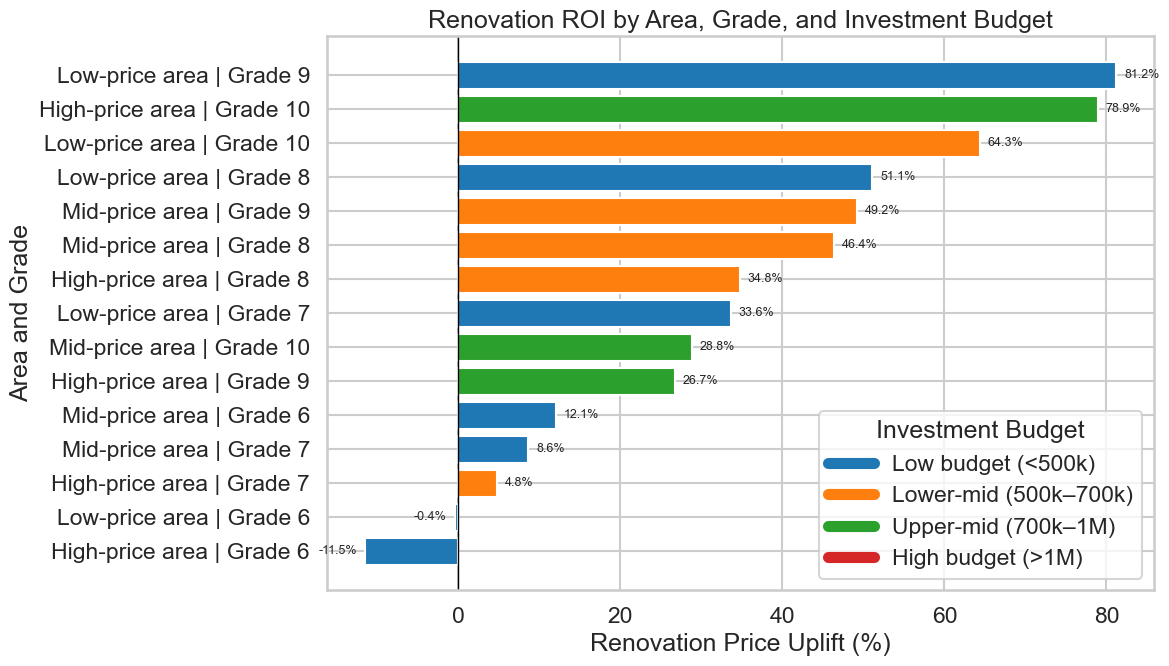

In [210]:
# ============================================================
# ROI Comparison Across Investment Budget Levels
# ============================================================

# Investment buckets based on baseline (no-renovation) price
bins = [-np.inf, 500_000, 700_000, 1_000_000, np.inf]
labels = [
    "Low budget (<500k)",
    "Lower-mid (500k–700k)",
    "Upper-mid (700k–1M)",
    "High budget (>1M)"
]

pivot_prices["investment_bucket"] = pd.cut(
    pivot_prices["median_no_renovation"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Prepare plot labels
plot_df = pivot_prices.copy()
plot_df["area_grade"] = (
    plot_df["zipcode_price_group"].astype(str)
    + " | Grade "
    + plot_df["grade"].astype(str)
)

# Sort by ROI
plot_df = plot_df.sort_values("pct_uplift", ascending=True)

# Color mapping by budget
cmap = plt.get_cmap("tab10")
bucket_to_color = {b: cmap(i) for i, b in enumerate(labels)}
bar_colors = plot_df["investment_bucket"].astype(str).map(bucket_to_color)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    plot_df["area_grade"],
    plot_df["pct_uplift"],
    color=bar_colors
)

ax.axvline(0, color="black", linewidth=1)
ax.set_title("Renovation ROI by Area, Grade, and Investment Budget")
ax.set_xlabel("Renovation Price Uplift (%)")
ax.set_ylabel("Area and Grade")

# Annotate bars
for y, v in enumerate(plot_df["pct_uplift"]):
    ax.text(
        v + (1 if v >= 0 else -1),
        y,
        f"{v:.1f}%",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=9
    )

# Legend
handles = [
    plt.Line2D([0], [0], color=bucket_to_color[b], lw=8, label=b)
    for b in labels
]
ax.legend(handles=handles, title="Investment Budget", loc="lower right")

plt.tight_layout()
plt.show()


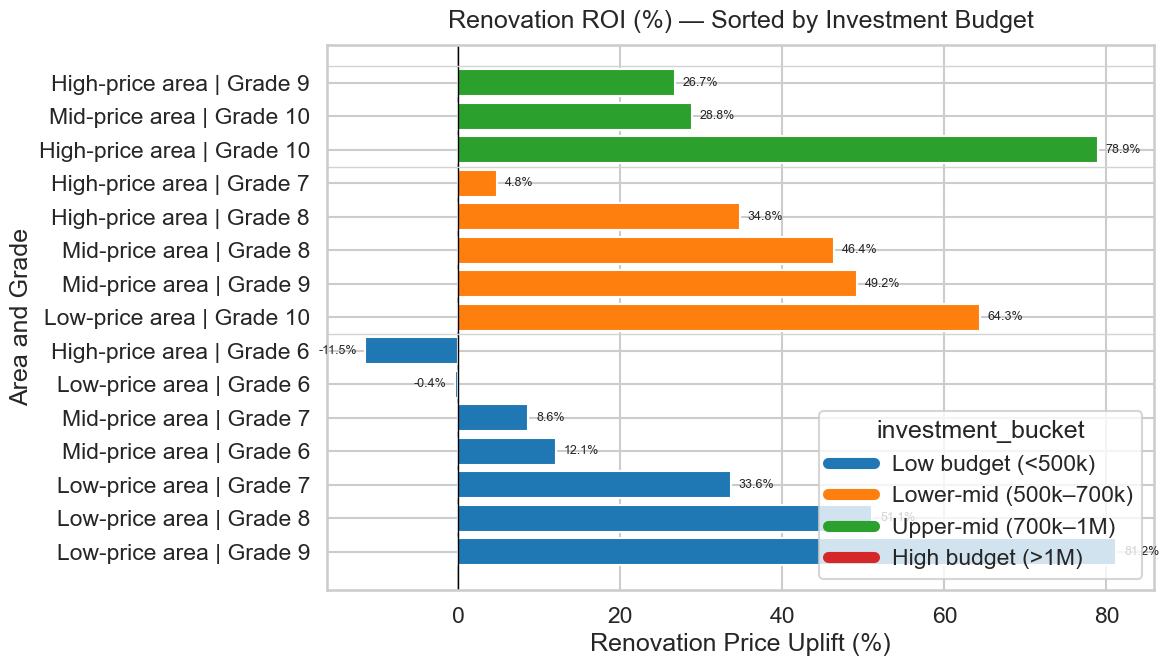

In [211]:

# --- Make a copy to avoid side effects
plot_df = pivot_prices.copy()

# --- Create readable y-label
plot_df["area_grade"] = (
    plot_df["zipcode_price_group"].astype(str)
    + " | Grade "
    + plot_df["grade"].astype(int).astype(str)
)

# --- Ensure bucket has a fixed order (budget first!)
bucket_order = [
    "Low budget (<500k)",
    "Lower-mid (500k–700k)",
    "Upper-mid (700k–1M)",
    "High budget (>1M)"
]
plot_df["investment_bucket"] = pd.Categorical(plot_df["investment_bucket"], categories=bucket_order, ordered=True)

# --- Sort by budget, then by ROI% (or switch to abs_uplift if you prefer)
plot_df = plot_df.sort_values(["investment_bucket", "pct_uplift"], ascending=[True, False]).reset_index(drop=True)

# --- Color mapping per bucket (stable)
cmap = plt.get_cmap("tab10")
bucket_to_color = {b: cmap(i) for i, b in enumerate(bucket_order)}
bar_colors = plot_df["investment_bucket"].astype(str).map(bucket_to_color).fillna("gray")

# --- Plot
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(plot_df["area_grade"], plot_df["pct_uplift"], color=bar_colors)

ax.axvline(0, color="black", linewidth=1)
ax.set_title("Renovation ROI (%) — Sorted by Investment Budget", pad=12)
ax.set_xlabel("Renovation Price Uplift (%)")
ax.set_ylabel("Area and Grade")

# --- Add % labels
for y, v in enumerate(plot_df["pct_uplift"].values):
    ax.text(
        v + (1 if v >= 0 else -1),
        y,
        f"{v:.1f}%",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=9
    )

# --- Add visual separators between budget groups
counts = plot_df["investment_bucket"].value_counts().reindex(bucket_order).fillna(0).astype(int)
cum = 0
for b in bucket_order[:-1]:
    cum += counts[b]
    ax.axhline(cum - 0.5, color="lightgray", linewidth=1)

# --- Legend
handles = [plt.Line2D([0], [0], color=bucket_to_color[b], lw=8, label=b) for b in bucket_order]
ax.legend(handles=handles, title="investment_bucket", loc="lower right")

plt.tight_layout()
plt.show()


**Observation** (based on Renovation ROI by Area, Grade, and Investment Budget)

Renovation ROI varies substantially across grade, location, and investment budget, indicating that renovation profitability is highly context-dependent rather than universal.

The highest ROI is achieved in mid-price areas for high-grade properties (Grade 11), particularly when paired with a high investment budget (>1M). This suggests that in mid-price neighborhoods, upgrading already high-quality homes can trigger a strong repositioning effect, allowing the property to move into a significantly higher price segment.

In low-price areas, renovation outcomes are mixed. While moderate positive ROI is observed for Grades 8–10, especially under lower to mid investment budgets, renovation of high-grade homes (Grade 11) in low-price areas can result in negative ROI, indicating over-investment relative to the local price ceiling. This highlights a strong location constraint on renovation returns.

In high-price areas, renovation consistently produces positive ROI across grades, but the relative percentage uplift is more moderate, particularly for mid grades. This suggests diminishing marginal returns, where high baseline prices limit the proportional impact of renovation, even though absolute price gains may still be substantial.

Overall, the results show that renovation ROI is maximized when investment budget, grade, and location are aligned. High budgets are most effective in mid-price areas with high grades, while cautious, lower-budget renovations are more suitable for low-price areas. Over-renovation in constrained markets appears to carry significant financial risk.

#### 3.3.4 Seasonality Effect: Sale Timing and Monthly Price Patterns
In this section, we analyze the seasonal pattern of housing prices by examining how average sale prices vary across different months of the year.
The goal is to understand whether timing of sale plays a role in achieved prices, which is particularly relevant for client decision-making regarding when to sell a property.

By aggregating sale prices at the monthly level, we can identify systematic fluctuations that may reflect market demand cycles, buyer behavior, and seasonal supply dynamics. This analysis helps isolate time-related effects from structural property characteristics such as location, grade, or renovation status.

In [212]:
# Extract selling month
df_housing['sale_date'] = pd.to_datetime(df_housing['sale_date'])
df_housing['sale_month'] = df_housing['sale_date'].dt.month

# Average price by month
monthly_avg = (
    df_housing
    .groupby('sale_month')['sale_price']
    .mean()
    .reset_index()
)

# Month labels
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg['month_name'] = monthly_avg['sale_month'].apply(lambda x: month_labels[x-1])


In [213]:
# Custom seasonal colors
colors = [
    '#9E9E9E', '#9E9E9E',        # Jan, Feb (winter)
    '#7CB342', '#66BB6A', '#81C784',  # Mar–May (spring)
    '#FDD835', '#FBC02D', '#F9A825',  # Jun–Aug (summer)
    '#EF6C00', '#E65100', '#F57C00',  # Sep–Nov (fall)
    '#9E9E9E'                     # Dec (winter)
]


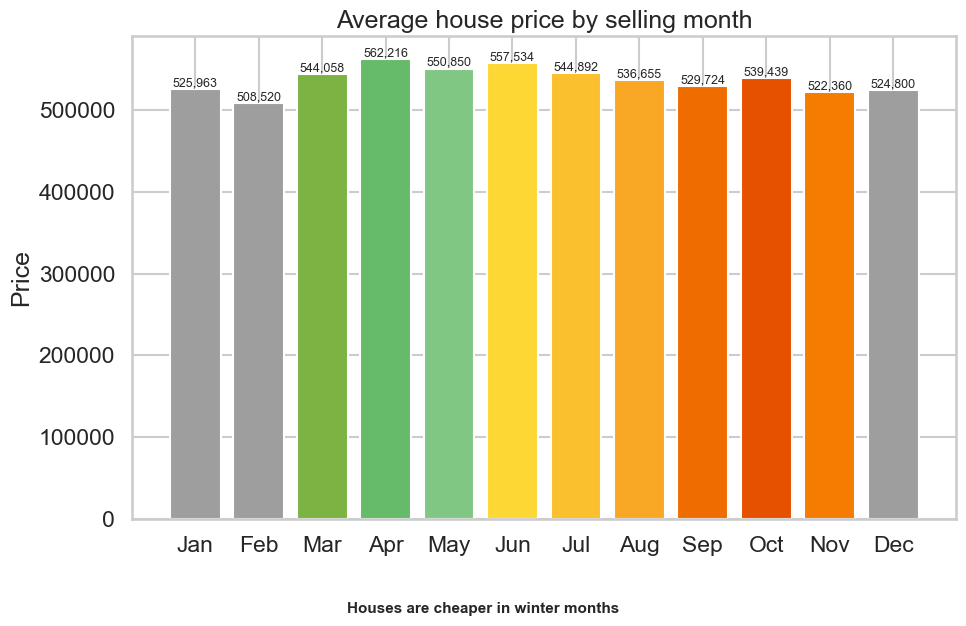

In [214]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    monthly_avg['month_name'],
    monthly_avg['sale_price'],
    color=colors
)

plt.ylabel('Price')
plt.title('Average house price by selling month')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Annotation at bottom
plt.figtext(
    0.5, -0.05,
    'Houses are cheaper in winter months',
    ha='center',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


**Observation (Timing Effect Based on One-Year Data)**

Based on the single year of available data, we observe a timing-related pattern in average sale prices.
Homes sold during the winter months (December, January, and February) show lower average sale prices compared to other months of the year. In particular, January and February exhibit the lowest average prices within this dataset.

From early spring onward, average sale prices increase and remain relatively higher through spring and early summer, before gradually declining again toward the end of the year.

It is important to note that, since this analysis is based on one year of observations only, these results should be interpreted as indicative patterns rather than confirmed seasonality. Nevertheless, the observed timing effect suggests that selling during winter months may be less favorable in terms of price compared to spring and early summer.

#### 3.3.5 Spatial Distribution of Price Levels (Zipcode-Based)
To complement the previous analyses, we now examine the spatial distribution of price levels across zipcodes. This visualization provides geographic context for the identified price segments and supports location-aware investment decisions.

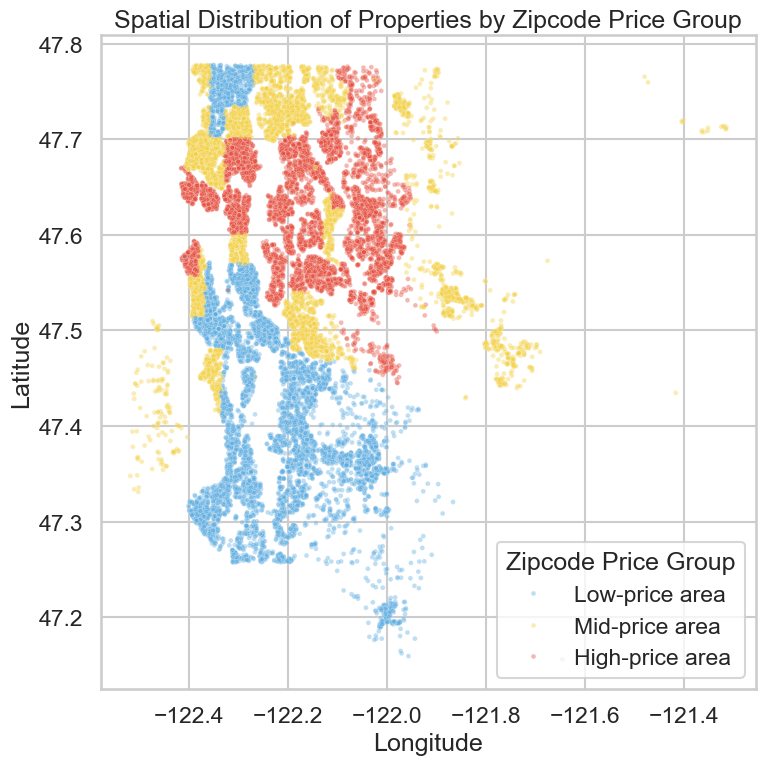

In [215]:

# Map zipcode price groups to colors
palette = {
    'Low-price area': '#5DADE2',   # blue
    'Mid-price area': '#F4D03F',   # yellow
    'High-price area': '#E74C3C'   # red
}

plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=df_housing,
    x='long',
    y='lat',
    hue='zipcode_price_group',
    palette=palette,
    alpha=0.4,
    s=12
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial Distribution of Properties by Zipcode Price Group')
plt.legend(title='Zipcode Price Group')

plt.tight_layout()
plt.show()


# Hypothesis 1 — Renovation Premium

**H1:**
Houses that have been renovated sell at higher prices than non-renovated houses.

**Evidence:**
The boxplot Sale Price by Renovation Status (using a logarithmic scale) shows that the median sale price of renovated houses is higher than that of non-renovated houses.
Although there is substantial overlap between the two price distributions, the central tendency (median) for renovated properties is clearly shifted upward.

**Conclusion:**
✅ Hypothesis H1 is supported.
On average, renovation is associated with higher sale prices. However, the overlap between distributions indicates that renovation alone does not guarantee a higher price for every property, suggesting that additional factors (such as property grade or price level) also play an important role.

## Hypothesis 2 — Effect of Grade on Sale Price and Renovation Impact

**H2:**
The quality grade of a property has a strong positive association with sale price, and the price premium from renovation depends heavily on the underlying grade of the house.

**Findings:**

Sale prices increase consistently with higher grades, regardless of renovation status. This indicates that grade is a dominant structural factor in determining house prices.

At lower grades (approximately grades 4–5), renovation has little to no clear impact on sale price. Renovated and non-renovated properties largely overlap in price, suggesting that renovation cannot compensate for low baseline quality.

From mid-range grades onward (around grade 7 and above), renovation begins to show a clearer positive price effect. Renovated houses generally sell at higher prices than non-renovated ones within the same grade.

At very high grades, grade itself remains the primary driver of price. While renovated properties still tend to achieve higher prices, the marginal benefit of renovation is smaller relative to the strong effect of grade.

**Conclusion:**

Grade is the primary driver of house prices, while renovation acts as a secondary, amplifying factor.
Renovation is most effective when applied to houses that already have a solid quality level, rather than low-grade properties.

## Hypothesis 3 – Grade Effect Depends on Area Price Level

**H3:**
The impact of grade on the sale price of renovated houses depends on the price level of the area (low-, mid-, or high-price areas).

**Findings**

The analysis shows that grade is a strong driver of sale price among renovated houses across all price levels. In general, higher-grade houses sell for higher prices even after renovation.

However, this effect is not uniform across area price levels:

Low-price areas:
Renovation and higher grades only lead to meaningful price increases from mid to higher grades (around grade 8 and above). At very high grades, the return from renovation becomes less predictable.

Mid-price areas:
The relationship between grade and sale price is the most stable and consistent. Grades 8–10 show clear and reliable price uplifts after renovation, making this segment particularly attractive for renovation investments.

High-price areas:
While higher grades correspond to higher sale prices, the relative benefit of renovation varies more. High baseline prices mean that renovation returns depend strongly on the available investment budget.

**Conclusion**

Hypothesis 3 is supported.
Grade significantly influences the sale price of renovated houses, but the strength and profitability of this effect depend on the area’s price level. Renovation strategies should therefore consider both grade and location price level rather than treating renovation returns as uniform across the market.

## Hypothesis 4 – Renovation Profitability Is Context-Dependent
**H4:**

Renovation does not always lead to a positive return on investment; its profitability depends on the property’s grade and the price level of the area.

**Findings**

The exploratory data analysis shows that renovation outcomes vary substantially across different combinations of area price level and property grade.

While renovation often increases sale prices, this increase is not uniform and does not always translate into a positive or meaningful return on investment.

Key observations include:

Low-price areas:
Renovation tends to generate positive returns mainly for mid-grade properties (approximately grades 8–9).
For very high-grade properties, renovation benefits become weak or even negative, suggesting potential over-investment relative to local market limits.

Mid-price areas:
This segment shows the most consistent and reliable renovation returns, particularly for grades 8–10.
Renovation in this range often leads to clear price uplifts, making it the most attractive context for renovation-driven value creation.

High-price areas:
Although absolute sale prices are high, renovation profitability becomes more sensitive to investment scale and budget.
High baseline prices reduce the relative impact of renovation, and returns vary widely depending on how much capital is invested.

**Conclusion**

Hypothesis 4 is not supported in a universal sense.
Renovation does not guarantee positive returns across all market segments. Instead, its profitability is strongly shaped by the interaction between property grade and area price level.

These findings highlight that renovation should be treated as a targeted investment strategy, not a one-size-fits-all solution. Successful renovation decisions require aligning the property’s quality level with the price capacity of its surrounding market.

## Client Recommendation – Renovation Decision Framework

Renovation is not always the right decision for maximizing sale price.
Our analysis shows that the profitability of renovation strongly depends on two key factors:
the house’s grade and the price level of the area in which it is located.

Before deciding whether to renovate, the seller should evaluate:

The grade of the property

The price level of the market segment the house belongs to
(low-, mid-, or high-price areas based on comparable sale prices, not necessarily geographic proximity)

When Renovation Is More Likely to Be Profitable
Low-price areas

Renovation can be beneficial only if the house already has a relatively high grade (around 7–8 or above).

For lower-grade houses, renovation often hits the local price ceiling and does not generate meaningful returns.

Mid-price areas

This segment offers the most consistent and reliable renovation outcomes.

Houses with grades between 8 and 10 show clear and stable price increases after renovation.

This makes mid-price areas the safest segment for renovation investments.

High-price areas

Renovation outcomes are more variable and budget-sensitive.

Renovation can be profitable when the house already has a high grade (above 10).

However, due to high baseline prices, renovation costs must be carefully evaluated, as returns are not guaranteed.

Final Recommendation to the Seller

Renovation should not be treated as a universal strategy.
It is most effective when applied to properties that already have solid quality and are located in market segments that can absorb higher prices.

If a house does not meet these conditions, selling without renovation may be the more rational and financially sound choice.